In [26]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

base_dir = r"D:\CPD_MPIA\HPC_eqC1_gap"
Gap = ["AA_Tau_gap0", "AA_Tau_gap1", "DM_Tau_gap1",
       "J1615_gap0", "LkCa_15_gap0", "SY_Cha_gap0", "V4046_Sgr_gap1"]
Inner_cavity = ["CQ_Tau_gap0", "DM_Tau_gap0", "HD_135344B_gap1", "J1604_gap0", "J1615_gap1", "J1852_gap0", "LkCa_15_gap1", "MWC_758_gap0"]

### This notebook produces summarised plot for the recovery cruves 

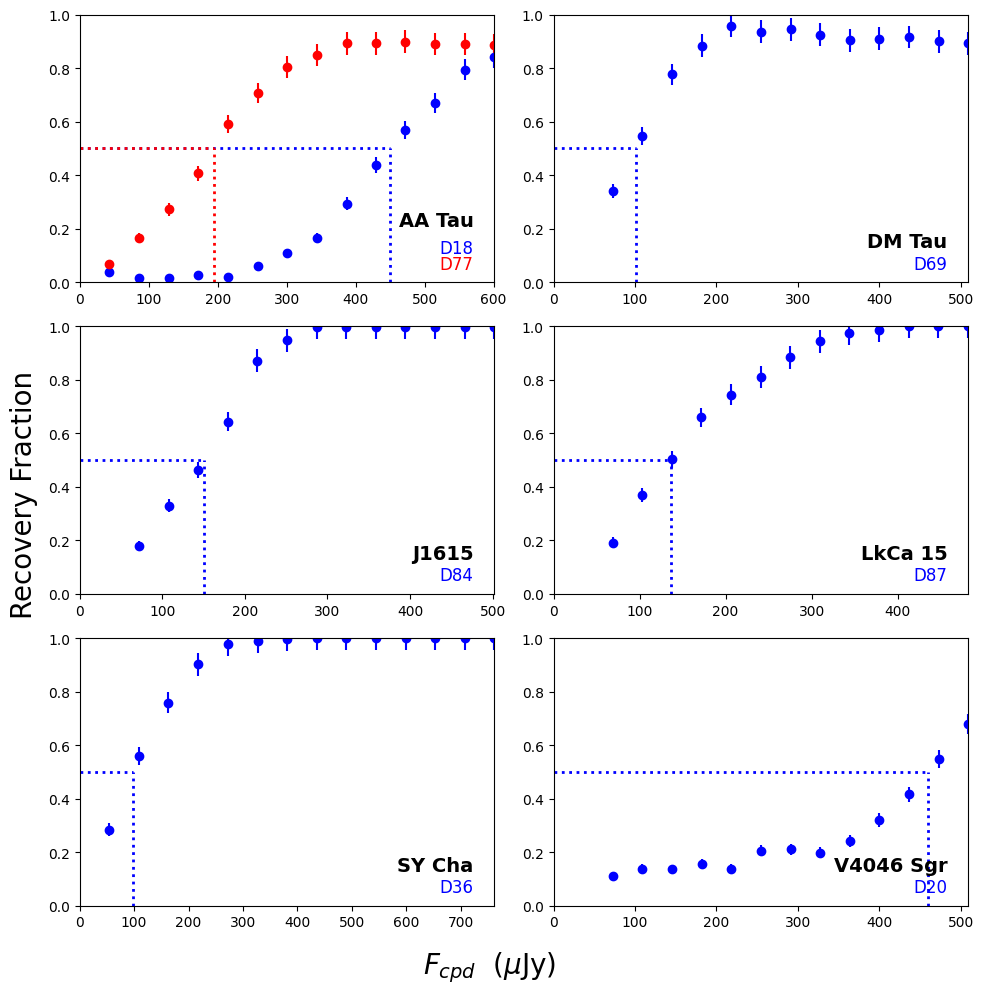

In [27]:
def f50(Fcpd, frec):
    i = np.argmax(frec >= 0.5)
    if i == 0:
        return Fcpd[0]
    x0, x1, y0, y1 = Fcpd[i - 1], Fcpd[i], frec[i - 1], frec[i]
    return x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)

disks = {}
for name in Gap:
    target = name.rsplit("_gap", 1)[0]
    disks.setdefault(target, []).append(name)

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for ax, (target, names) in zip(axes.flat, disks.items()):
    ax.text(0.95, 0.05 + 0.08 * len(names), target.replace("_", " "), transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
    for j, (name, c) in enumerate(zip(names, ["b", "r"])):
        Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/gap/{name}/recoveries/{name}_rprofs.combined.txt").T
        ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color=c, ls="none", capsize=0.0, elinewidth=1.5)
        F50 = f50(Fcpd, frec_B)
        ax.hlines(0.5, 0, F50, color=c, ls=":", lw=2, alpha=1)
        ax.vlines(F50, 0, 0.5, color=c, ls=":", lw=2, alpha=1)
        gap_ix = int(name.rsplit("_gap", 1)[1])
        D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
        ax.text(0.95, 0.05 + 0.06 * (len(names) - 1 - j), f"D{D_au:.0f}", color=c, transform=ax.transAxes, ha="right", fontsize=12)
        ax.set_xlim(0,np.max(Fcpd))
    ax.set_ylim(0, 1)
    
for ax in axes.flat[len(disks):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize = 20)
fig.supylabel("Recovery Fraction" , fontsize = 20)
fig.tight_layout()
plt.show()


# word need larger and bold , 
# AA tau inner gap 
# strip off those underscores in text
# that 50 per cent line need to get thicker

In [28]:
Gap_f50 = Gap + ["HD_135344B_gap0"]          # HD_135344B_gap0 has a complete combined file but was left out of Gap above
InnerCavity_f50 = Inner_cavity + ["V4046_Sgr_gap0"]   # V4046_Sgr_gap0 has since been run

print(f"{'category':<14}{'name':<20}{'D (au)':>8}{'F50 (uJy)':>12}{'F50 (sigma)':>13}")
for cat, sub, names in [("gap", "gap", Gap_f50), ("inner cavity", "inner_cavity", InnerCavity_f50)]:
    for name in names:
        target, gap_ix = name.rsplit("_gap", 1)
        gap_ix = int(gap_ix)
        Fcpd, _, _, _, frec_B, _, _ = np.loadtxt(f"{base_dir}/{sub}/{name}/recoveries/{name}_rprofs.combined.txt").T
        D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
        never_reaches = frec_B.max() < 0.5
        starts_above = frec_B[0] >= 0.5
        F50 = f50(Fcpd, frec_B) if not never_reaches else np.nan
        F50_sigma = F50 / diskdict.disk[target]["RMS"]
        flag = ("  <- never reaches 50%" if never_reaches else
                "  <- already >=50% at lowest tested flux (upper bound only)" if starts_above else "")
        print(f"{cat:<14}{name:<20}{D_au:>8.0f}{F50:>12.1f}{F50_sigma:>13.2f}{flag}")

print("\nNever reach 50% (checked the raw *_recoveries.combined.txt -- in both cases the")
print("'recovered' peak sits at one fixed sky position on every single trial, regardless")
print("of injected flux or position, i.e. the search annulus contains a persistent bright")
print("residual feature that always wins the peak-finding, not a pipeline bug):")
print("  HD_135344B_gap0 -- fixed peak at (-0.037\", -0.543\"), ~2.8-3.1 mJy/beam, local rms~870 uJy")
print("                     (outer ring gap annulus sits on a strong disk residual structure)")
print("  MWC_758_gap1    -- fixed peak at r=0.465\", az=-161 deg, ~1.4 mJy/beam (~25x RMS)")
print("                     tested flux only goes to 800 uJy, nowhere near that residual")

print("\nJ1615_gap1 -- recovery fraction is flat at ~0.73-0.85 across the ENTIRE tested range")
print("  (36 to 502 uJy, more than an order of magnitude), even after adding a lower 1-sigma")
print("  bin specifically to chase this down. Root cause: rgap=0.04\" is *smaller* than the")
print("  beam FWHM (0.085\"), i.e. the injection/search region is sub-beam -- the pipeline")
print("  can't distinguish a recovered fake source from the always-present beam-smeared")
print("  central emission at this radius. F50 here is not physically meaningful.")
print("LkCa_15_gap1 -- by contrast, rgap=0.06\" ~ beam FWHM (0.061\") but the curve rises")
print("  normally (0.50 -> 0.59 -> 0.71 -> ... -> 1.0); the new 1-sigma point (34 uJy) landed")
print("  almost exactly on the 50% crossing, so its F50 above is a real, well-anchored value.")

category      name                  D (au)   F50 (uJy)  F50 (sigma)
gap           AA_Tau_gap0               18       449.2        10.46
gap           AA_Tau_gap1               77       194.0         4.52
gap           DM_Tau_gap1               69       101.0         2.78
gap           J1615_gap0                84       150.2         4.19
gap           LkCa_15_gap0              87       137.0         3.98
gap           SY_Cha_gap0               36        97.4         1.79
gap           V4046_Sgr_gap1            20       459.5        12.64
gap           HD_135344B_gap0           67         nan          nan  <- never reaches 50%
inner cavity  CQ_Tau_gap0                6       323.3         8.26
inner cavity  DM_Tau_gap0               12       182.0         5.00
inner cavity  HD_135344B_gap1           12       253.6         5.68
inner cavity  J1604_gap0                52       156.3         3.96
inner cavity  J1615_gap1                 6        36.0         1.00  <- already >=50% at lowes

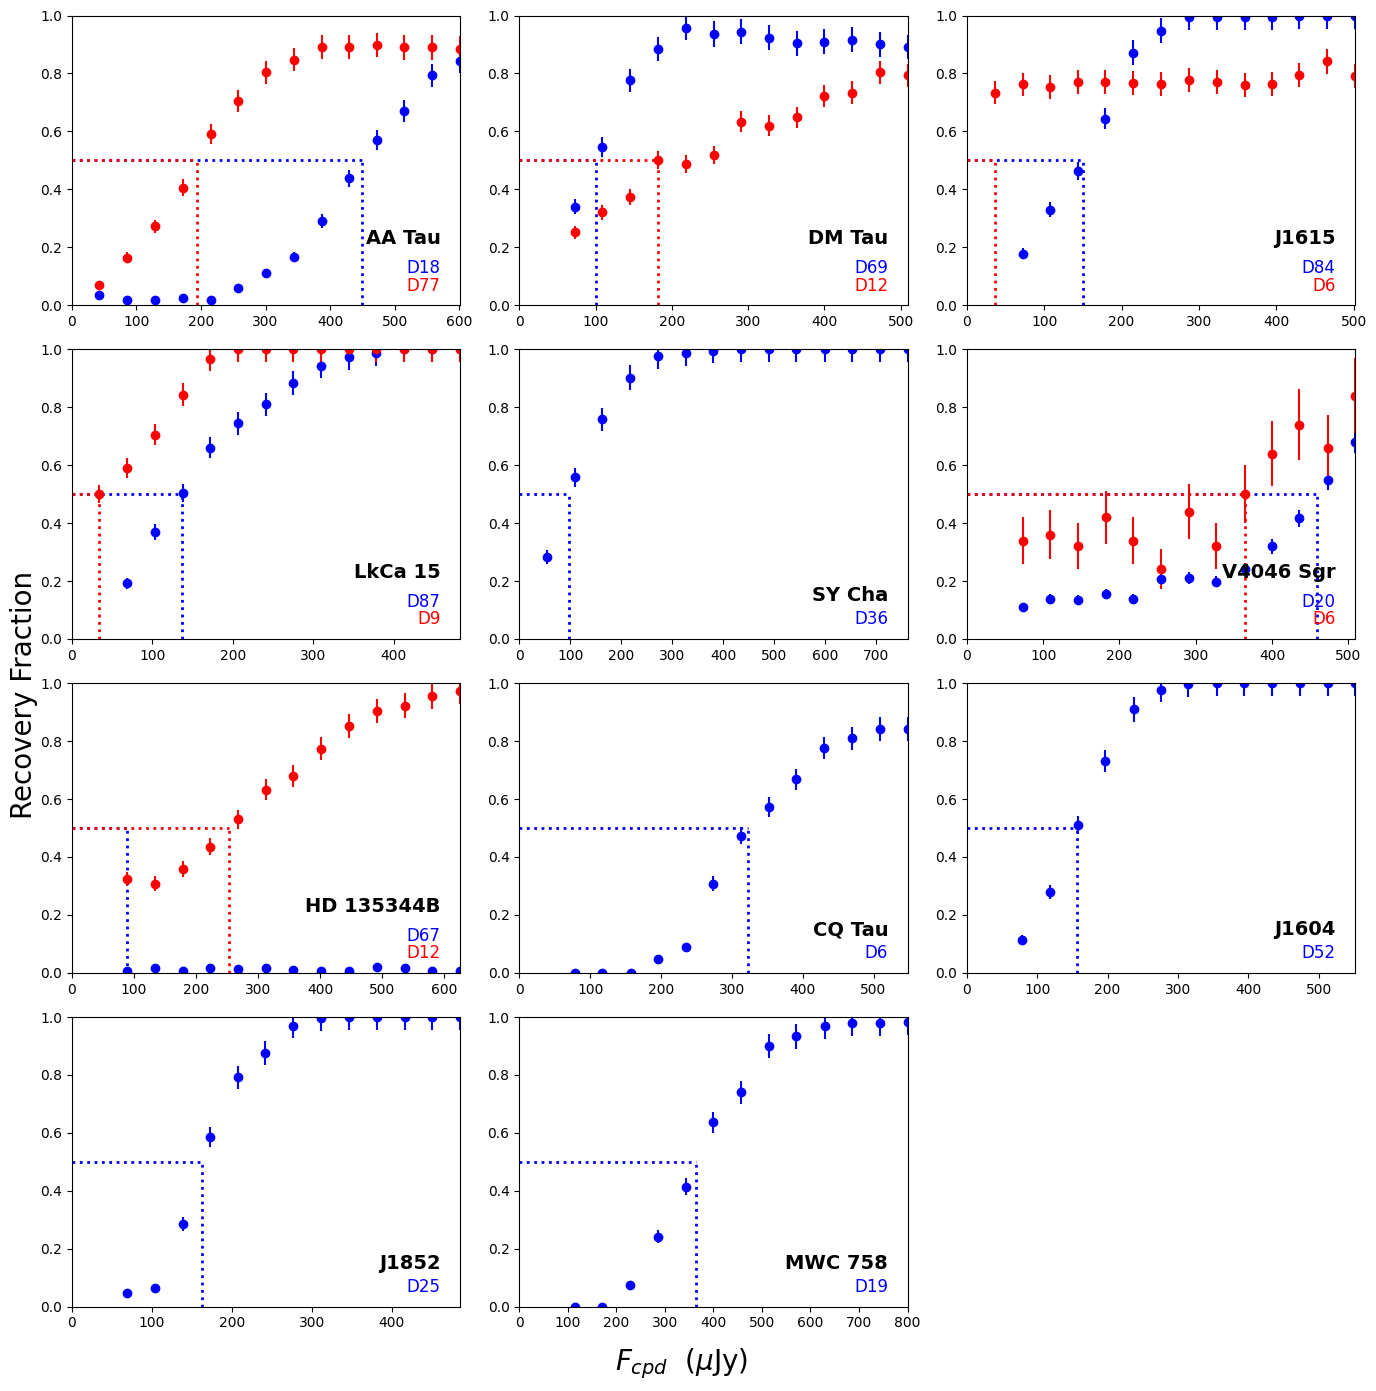

In [29]:
AllGaps = [(name, "gap") for name in Gap] + [("HD_135344B_gap0", "gap")] + \
          [(name, "inner_cavity") for name in Inner_cavity] + [("V4046_Sgr_gap0", "inner_cavity")]

disks_all = {}
for name, sub in AllGaps:
    target = name.rsplit("_gap", 1)[0]
    disks_all.setdefault(target, []).append((name, sub))

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for ax, (target, entries) in zip(axes.flat, disks_all.items()):
    ax.text(0.95, 0.05 + 0.08 * len(entries), target.replace("_", " "), transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
    for j, ((name, sub), c) in enumerate(zip(entries, ["b", "r"])):
        Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/{sub}/{name}/recoveries/{name}_rprofs.combined.txt").T
        ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color=c, ls="none", capsize=0.0, elinewidth=1.5)
        F50 = f50(Fcpd, frec_B)
        ax.hlines(0.5, 0, F50, color=c, ls=":", lw=2, alpha=1)
        ax.vlines(F50, 0, 0.5, color=c, ls=":", lw=2, alpha=1)
        gap_ix = int(name.rsplit("_gap", 1)[1])
        D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
        ax.text(0.95, 0.05 + 0.06 * (len(entries) - 1 - j), f"D{D_au:.0f}", color=c, transform=ax.transAxes, ha="right", fontsize=12)
        ax.set_xlim(0, np.max(Fcpd))
    ax.set_ylim(0, 1)

for ax in axes.flat[len(disks_all):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=20)
fig.supylabel("Recovery Fraction", fontsize=20)
fig.tight_layout()
plt.show()

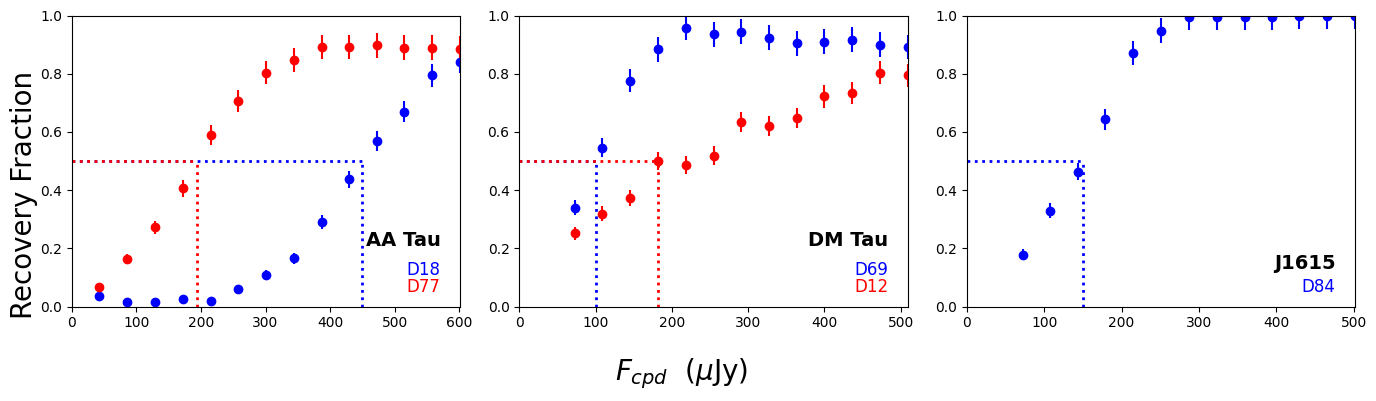

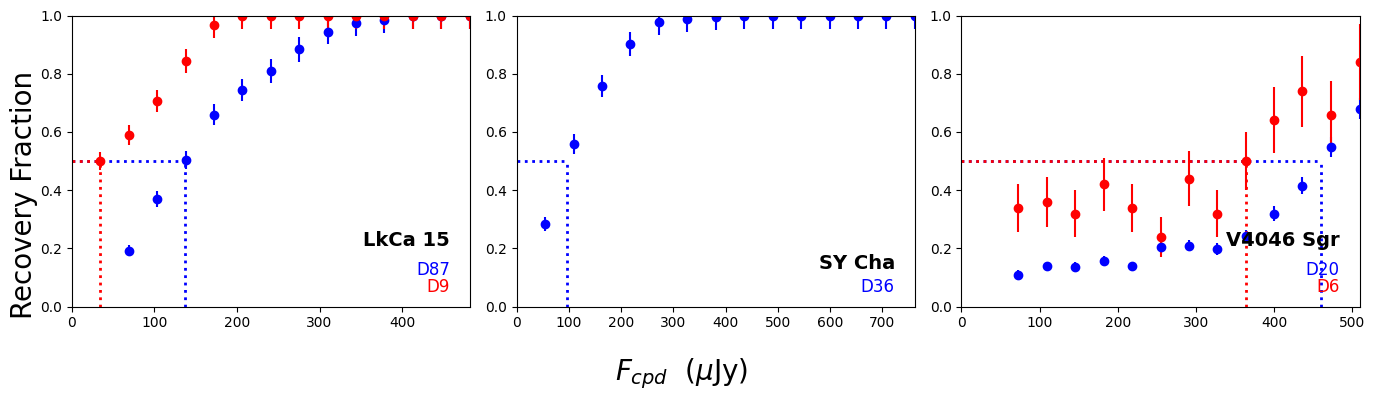

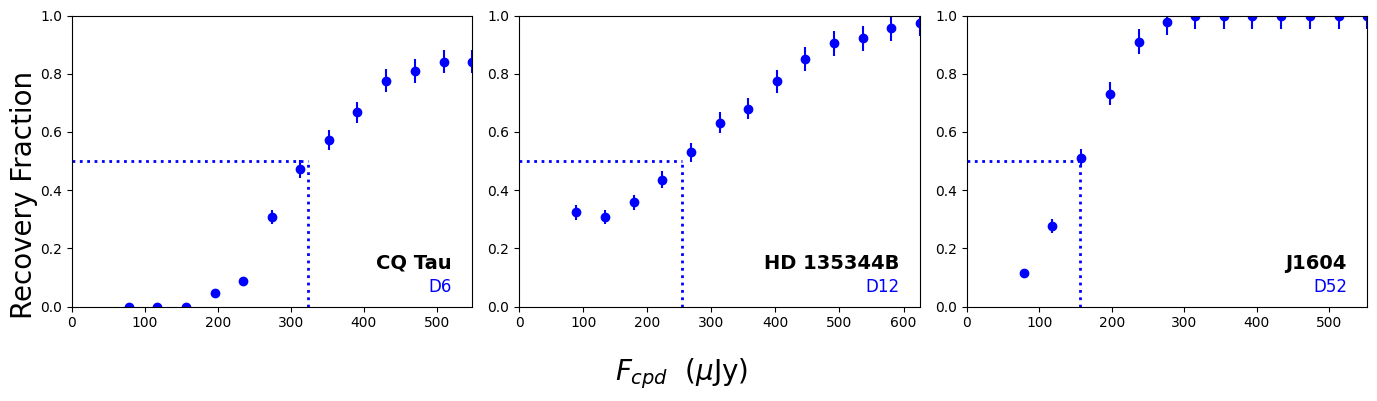

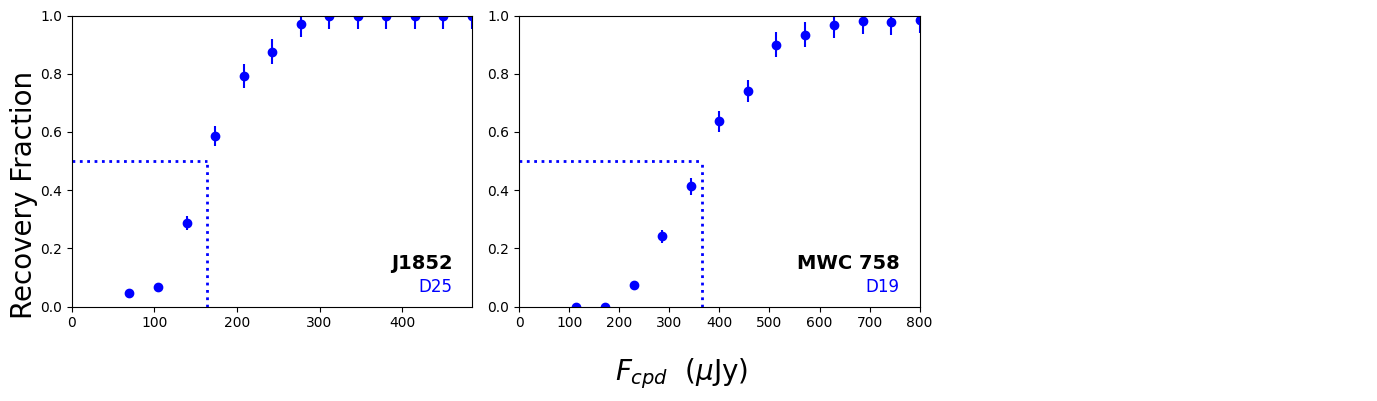

In [30]:
# curated version of the combined gap+inner_cavity grid above -- drops
# HD_135344B_gap0 (D67, never reaches 50%, fixed contaminating residual) and
# J1615_gap1 (D6, sub-beam gap radius, F50 not physically meaningful).
# Split into several 3-column plots instead of one big grid.
AllGaps_curated = [x for x in AllGaps if x[0] not in ("HD_135344B_gap0", "J1615_gap1")]

disks_curated = {}
for name, sub in AllGaps_curated:
    target = name.rsplit("_gap", 1)[0]
    disks_curated.setdefault(target, []).append((name, sub))

items = list(disks_curated.items())
for start in range(0, len(items), 3):
    chunk = items[start:start + 3]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (target, entries) in zip(axes, chunk):
        ax.text(0.95, 0.05 + 0.08 * len(entries), target.replace("_", " "), transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
        for j, ((name, sub), c) in enumerate(zip(entries, ["b", "r"])):
            Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/{sub}/{name}/recoveries/{name}_rprofs.combined.txt").T
            ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color=c, ls="none", capsize=0.0, elinewidth=1.5)
            F50 = f50(Fcpd, frec_B)
            ax.hlines(0.5, 0, F50, color=c, ls=":", lw=2, alpha=1)
            ax.vlines(F50, 0, 0.5, color=c, ls=":", lw=2, alpha=1)
            gap_ix = int(name.rsplit("_gap", 1)[1])
            D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
            ax.text(0.95, 0.05 + 0.06 * (len(entries) - 1 - j), f"D{D_au:.0f}", color=c, transform=ax.transAxes, ha="right", fontsize=12)
            ax.set_xlim(0, np.max(Fcpd))
        ax.set_ylim(0, 1)

    for ax in axes[len(chunk):]:
        ax.axis("off")
    fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=20)
    fig.supylabel("Recovery Fraction", fontsize=20)
    fig.tight_layout()
    plt.show()

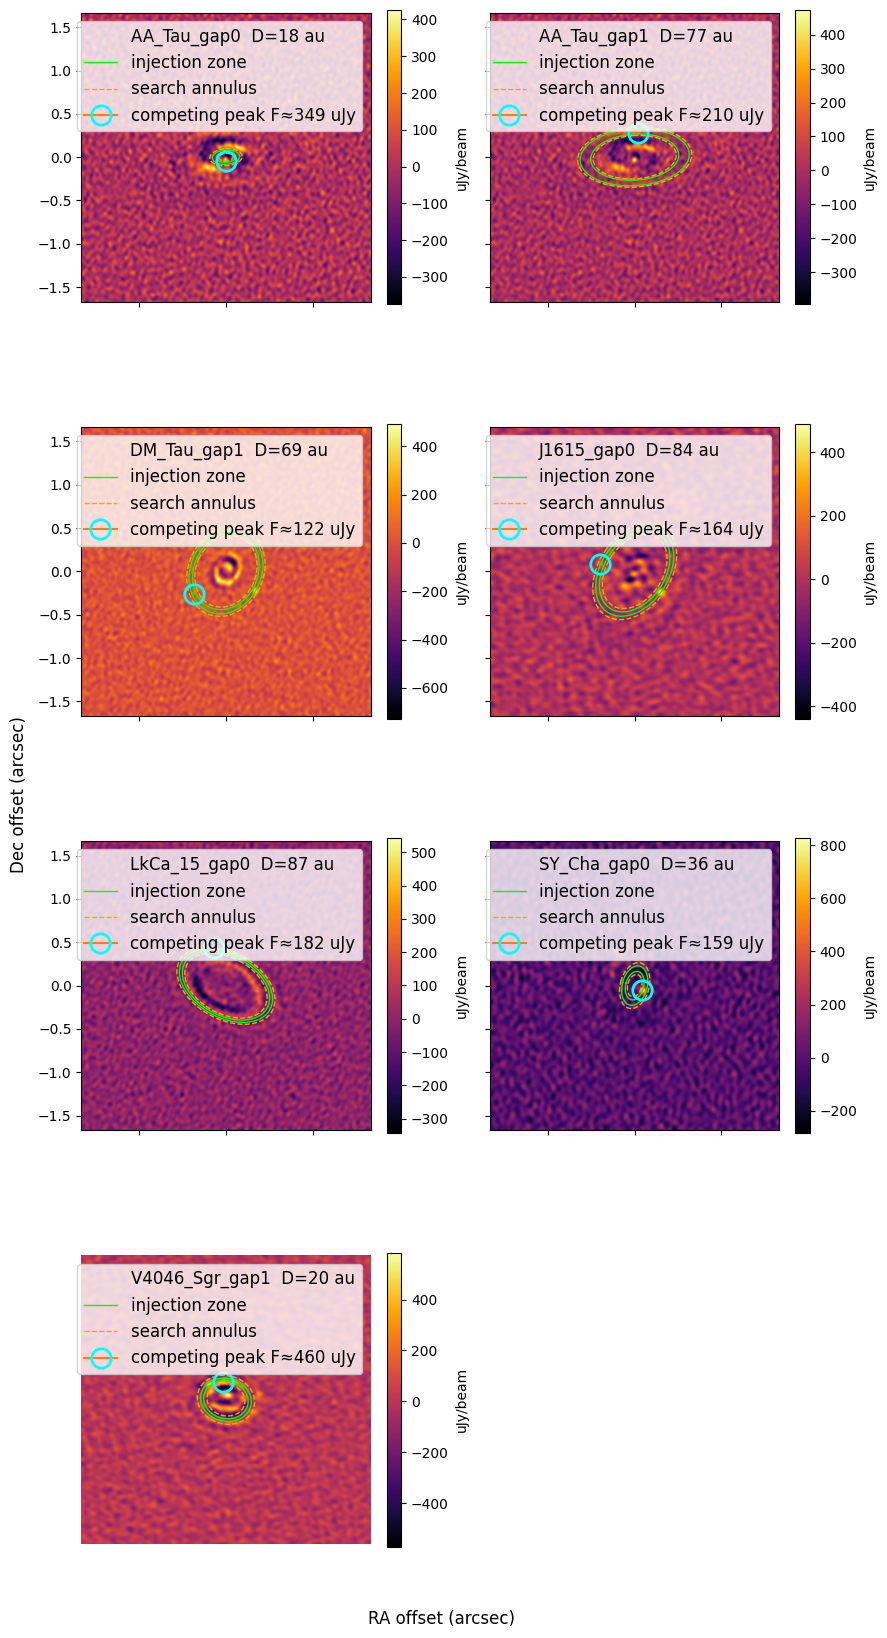

In [31]:
import glob
from astropy.io import fits

def polar_to_sky(r, az, PAr, inclr):
    x = r * np.sin(az) * np.sin(PAr) + r * np.cos(az) * np.cos(inclr) * np.cos(PAr)
    y = r * np.sin(az) * np.cos(PAr) - r * np.cos(az) * np.cos(inclr) * np.sin(PAr)
    return x, y

az_trace = np.radians(np.linspace(-180, 180, 361))
npix_tol, ast_tol = 2, 2

fig, axes = plt.subplots(4, 2, figsize=(9, 17), sharex=True, sharey=True)
for ax, name in zip(axes.flat, Gap):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)
    rgap = diskdict.disk[target]["rgap"][gap_ix]
    wgap = diskdict.disk[target]["wgap"][gap_ix]
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])
    dx, dy = diskdict.disk[target]["dx"], diskdict.disk[target]["dy"]
    D_au = rgap * diskdict.disk[target]["distance"]

    f = sorted(glob.glob(f"{base_dir}/gap/{name}/recoveries/*.resid.fits"))[0]
    hdu = fits.open(f)
    img = 1e6 * np.squeeze(hdu[0].data)
    hd = hdu[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])
    pix_size = np.abs(3600 * hd["CDELT2"])

    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - dx, RAo[-1] - dx, DECo[0] - dy, DECo[-1] - dy]

    search_span = 0.5 * wgap + 0.5 * beam_fwhm
    x_inj_lo, y_inj_lo = polar_to_sky(rgap - 0.5 * wgap, az_trace, PAr, inclr)
    x_inj_hi, y_inj_hi = polar_to_sky(rgap + 0.5 * wgap, az_trace, PAr, inclr)
    x_s_lo, y_s_lo = polar_to_sky(rgap - search_span, az_trace, PAr, inclr)
    x_s_hi, y_s_hi = polar_to_sky(rgap + search_span, az_trace, PAr, inclr)

    # competing peak: most common recovered position among the astrometric-criterion failures
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(f"{base_dir}/gap/{name}/recoveries/{name}_recoveries.combined.txt").T
    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)
    sigma_A = (4 / np.pi) ** 0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    dlim_A = np.maximum(ast_tol * sigma_A, npix_tol * pix_size)
    fail = d_ir > dlim_A
    vals, cts = np.unique(np.stack([Fr[fail], rr[fail], azr[fail]], axis=-1), return_counts=True, axis=0)
    mark_flux, mark_r, mark_az = vals[np.argmax(cts)]
    mark_x, mark_y = polar_to_sky(mark_r, np.radians(mark_az), PAr, inclr)

    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    plt.colorbar(im, ax=ax, fraction=0.046, label="uJy/beam")
    ax.plot([], [], " ", label=f"{name}  D={D_au:.0f} au")
    ax.plot(x_inj_lo, y_inj_lo, color="lime", lw=1)
    ax.plot(x_inj_hi, y_inj_hi, color="lime", lw=1, label="injection zone")
    ax.plot(x_s_lo, y_s_lo, color="orange", ls="--", lw=1)
    ax.plot(x_s_hi, y_s_hi, color="orange", ls="--", lw=1, label="search annulus")
    ax.plot(mark_x, mark_y, marker="o", markerfacecolor="none", markeredgecolor="cyan",
            markersize=14, markeredgewidth=2, label=f"competing peak F≈{mark_flux:.0f} uJy")
    zoom = 5 * (rgap + search_span)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.legend(fontsize=12, loc="upper right")
    ax.label_outer()

for ax in axes.flat[len(disks):]:
    ax.axis("off")
fig.supxlabel("RA offset (arcsec)")
fig.supylabel("Dec offset (arcsec)")
fig.tight_layout()
plt.show()

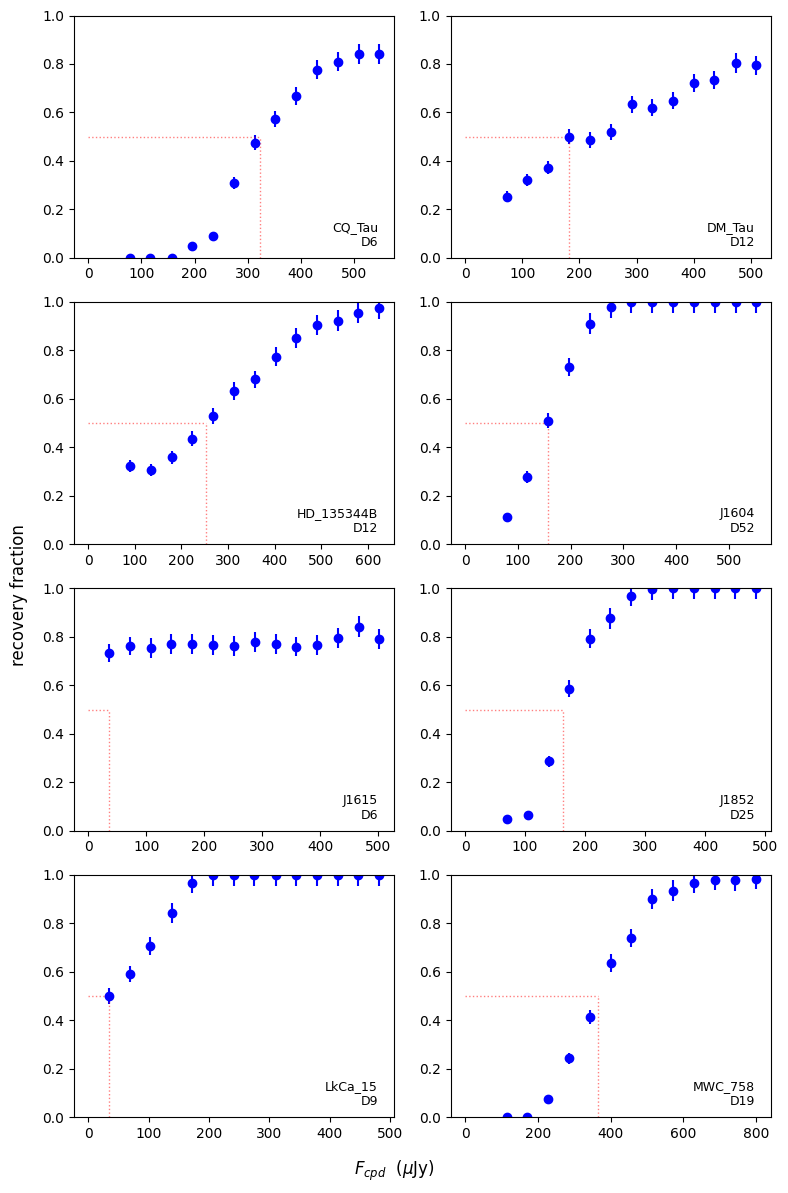

In [32]:
fig, axes = plt.subplots(4, 2, figsize=(8, 12))
for ax, name in zip(axes.flat, Inner_cavity):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)
    Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/inner_cavity/{name}/recoveries/{name}_rprofs.combined.txt").T
    ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="b", ls="none", capsize=0.0, elinewidth=1.5)
    F50 = f50(Fcpd, frec_B)
    ax.hlines(0.5, 0, F50, color="r", ls=":", lw=1, alpha=0.5)
    ax.vlines(F50, 0, 0.5, color="r", ls=":", lw=1, alpha=0.5)
    D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
    ax.text(0.95, 0.05, f"{target}\nD{D_au:.0f}", transform=ax.transAxes, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)")
fig.supylabel("recovery fraction")
fig.tight_layout()
plt.show()

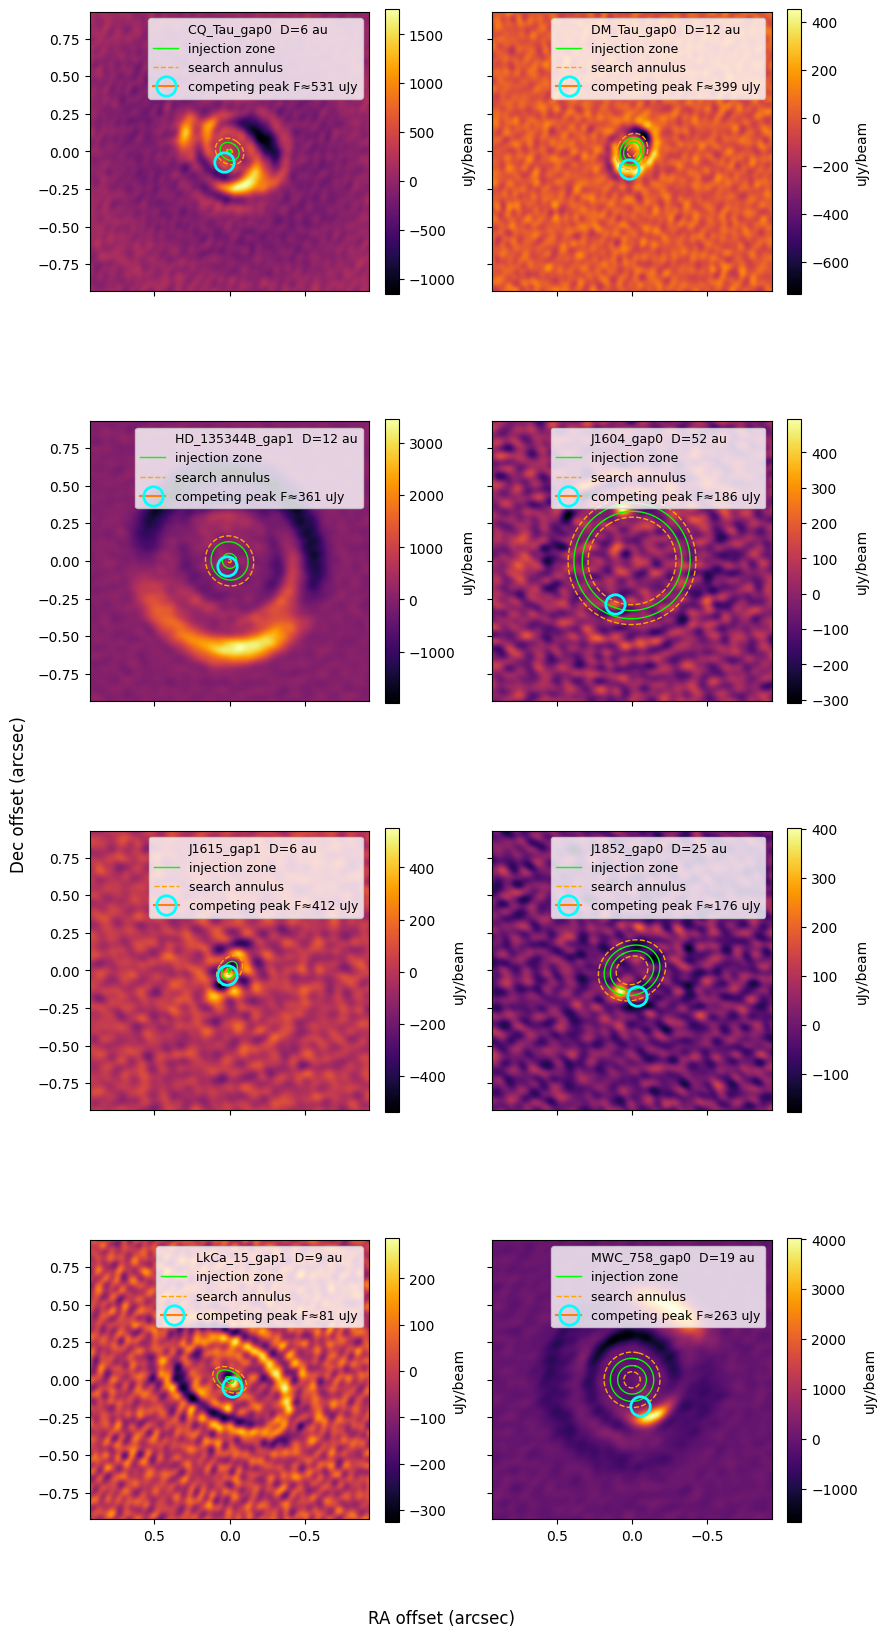

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(9, 17), sharex=True, sharey=True)
for ax, name in zip(axes.flat, Inner_cavity):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)
    rgap = diskdict.disk[target]["rgap"][gap_ix]
    wgap = diskdict.disk[target]["wgap"][gap_ix]
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])
    dx, dy = diskdict.disk[target]["dx"], diskdict.disk[target]["dy"]
    D_au = rgap * diskdict.disk[target]["distance"]

    f = sorted(glob.glob(f"{base_dir}/inner_cavity/{name}/recoveries/*.resid.fits"))[0]
    hdu = fits.open(f)
    img = 1e6 * np.squeeze(hdu[0].data)
    hd = hdu[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])
    pix_size = np.abs(3600 * hd["CDELT2"])

    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - dx, RAo[-1] - dx, DECo[0] - dy, DECo[-1] - dy]

    search_span = 0.5 * wgap + 0.5 * beam_fwhm
    x_inj_lo, y_inj_lo = polar_to_sky(rgap - 0.5 * wgap, az_trace, PAr, inclr)
    x_inj_hi, y_inj_hi = polar_to_sky(rgap + 0.5 * wgap, az_trace, PAr, inclr)
    x_s_lo, y_s_lo = polar_to_sky(rgap - search_span, az_trace, PAr, inclr)
    x_s_hi, y_s_hi = polar_to_sky(rgap + search_span, az_trace, PAr, inclr)

    # competing peak: most common recovered position among the astrometric-criterion failures
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(f"{base_dir}/inner_cavity/{name}/recoveries/{name}_recoveries.combined.txt").T
    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)
    sigma_A = (4 / np.pi) ** 0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    dlim_A = np.maximum(ast_tol * sigma_A, npix_tol * pix_size)
    fail = d_ir > dlim_A
    vals, cts = np.unique(np.stack([Fr[fail], rr[fail], azr[fail]], axis=-1), return_counts=True, axis=0)
    mark_flux, mark_r, mark_az = vals[np.argmax(cts)]
    mark_x, mark_y = polar_to_sky(mark_r, np.radians(mark_az), PAr, inclr)

    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    plt.colorbar(im, ax=ax, fraction=0.046, label="uJy/beam")
    ax.plot([], [], " ", label=f"{name}  D={D_au:.0f} au")
    ax.plot(x_inj_lo, y_inj_lo, color="lime", lw=1)
    ax.plot(x_inj_hi, y_inj_hi, color="lime", lw=1, label="injection zone")
    ax.plot(x_s_lo, y_s_lo, color="orange", ls="--", lw=1)
    ax.plot(x_s_hi, y_s_hi, color="orange", ls="--", lw=1, label="search annulus")
    ax.plot(mark_x, mark_y, marker="o", markerfacecolor="none", markeredgecolor="cyan",
            markersize=14, markeredgewidth=2, label=f"competing peak F≈{mark_flux:.0f} uJy")
    zoom = 5 * (rgap + search_span)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.legend(fontsize=9, loc="upper right")
    ax.label_outer()

for ax in axes.flat[len(Inner_cavity):]:
    ax.axis("off")
fig.supxlabel("RA offset (arcsec)")
fig.supylabel("Dec offset (arcsec)")
fig.tight_layout()
plt.show()

Question： Why even at low flux do they have high recovery rate? 

In [34]:
# make the comparision plot with normal gap 

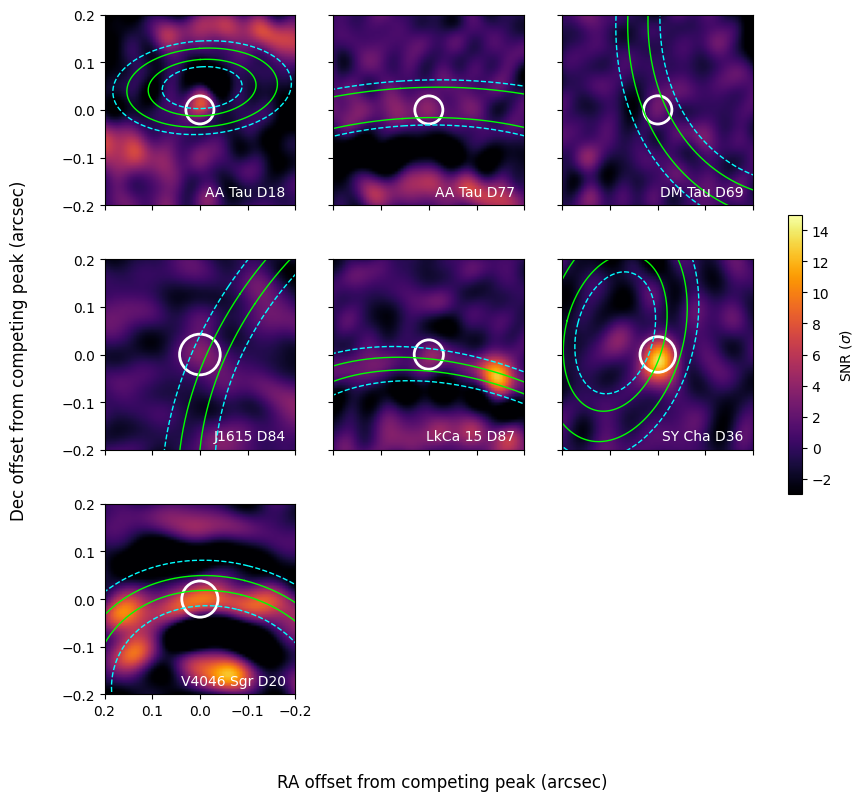

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)
for ax, name in zip(axes.flat, Gap):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)
    rgap = diskdict.disk[target]["rgap"][gap_ix]
    wgap = diskdict.disk[target]["wgap"][gap_ix]
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])
    dx, dy = diskdict.disk[target]["dx"], diskdict.disk[target]["dy"]
    D_au = rgap * diskdict.disk[target]["distance"]

    f = sorted(glob.glob(f"{base_dir}/gap/{name}/recoveries/*.resid.fits"))[0]
    hdu = fits.open(f)
    img = 1e6 * np.squeeze(hdu[0].data)
    hd = hdu[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])
    pix_size = np.abs(3600 * hd["CDELT2"])

    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))

    # competing peak: most common recovered position among the astrometric-criterion failures
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(f"{base_dir}/gap/{name}/recoveries/{name}_recoveries.combined.txt").T
    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)
    sigma_A = (4 / np.pi) ** 0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    dlim_A = np.maximum(ast_tol * sigma_A, npix_tol * pix_size)
    fail = d_ir > dlim_A
    vals, cts = np.unique(np.stack([Fr[fail], rr[fail], azr[fail]], axis=-1), return_counts=True, axis=0)
    mark_flux, mark_r, mark_az = vals[np.argmax(cts)]
    mark_x, mark_y = polar_to_sky(mark_r, np.radians(mark_az), PAr, inclr)

    extent = [RAo[0] - dx - mark_x, RAo[-1] - dx - mark_x, DECo[0] - dy - mark_y, DECo[-1] - dy - mark_y]
    img_sigma = img / np.std(img)

    # injection zone / search annulus, recentered on the competing peak the same way as the image
    search_span = 0.5 * wgap + 0.5 * beam_fwhm
    x_inj_lo, y_inj_lo = polar_to_sky(rgap - 0.5 * wgap, az_trace, PAr, inclr)
    x_inj_hi, y_inj_hi = polar_to_sky(rgap + 0.5 * wgap, az_trace, PAr, inclr)
    x_s_lo, y_s_lo = polar_to_sky(rgap - search_span, az_trace, PAr, inclr)
    x_s_hi, y_s_hi = polar_to_sky(rgap + search_span, az_trace, PAr, inclr)

    im = ax.imshow(img_sigma, origin="lower", cmap="inferno", extent=extent, vmin=-3, vmax=15)
    ax.plot(x_inj_lo - mark_x, y_inj_lo - mark_y, color="lime", lw=1)
    ax.plot(x_inj_hi - mark_x, y_inj_hi - mark_y, color="lime", lw=1)
    ax.plot(x_s_lo - mark_x, y_s_lo - mark_y, color="cyan", ls="--", lw=1)
    ax.plot(x_s_hi - mark_x, y_s_hi - mark_y, color="cyan", ls="--", lw=1)
    ax.add_patch(plt.Circle((0, 0), beam_fwhm / 2, facecolor="none", edgecolor="white", lw=2))
    ax.text(0.95, 0.05, f"{target.replace('_', ' ')} D{D_au:.0f}", transform=ax.transAxes, ha="right", fontsize=10, color="white")
    ax.label_outer()

for ax in axes.flat[len(Gap):]:
    ax.axis("off")
axes[0, 0].set_xlim(0.2, -0.2)
axes[0, 0].set_ylim(-0.2, 0.2)
fig.supxlabel("RA offset from competing peak (arcsec)")
fig.supylabel("Dec offset from competing peak (arcsec)")
fig.colorbar(im, ax=axes, fraction=0.02, label=r"SNR ($\sigma$)")
plt.show()

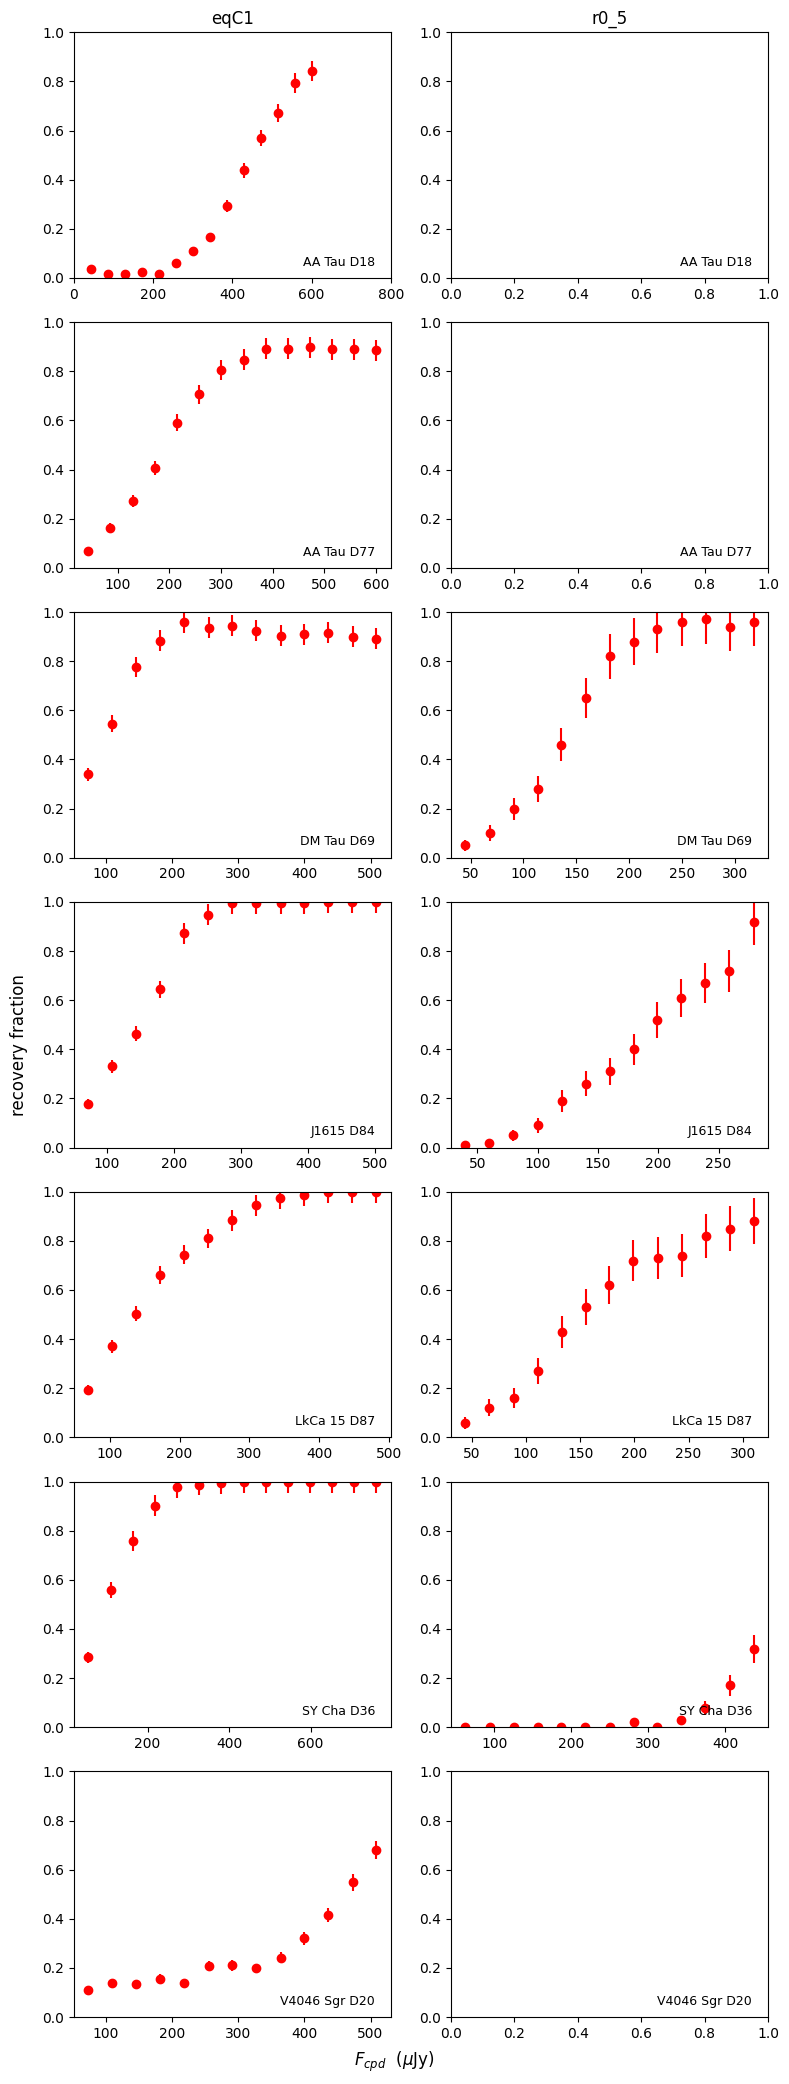

In [36]:
# comparison plot 
# Even though frank profile has revealed some sort of hidden features , they also cause wigglies due to more transtion reigon , steep 
# I want to defining gap in frank profile
# for the all gaps, plot the failed ones too

import os

# eqC1 name -> r0_5 name, matched by physical gap radius (not index -- the two
# methods don't share gap numbering), from the r-location comparison above
r0_5_map = {
    "AA_Tau_gap1": "AA_Tau_gap2",
    "DM_Tau_gap1": "DM_Tau_gap1",
    "J1615_gap0": "J1615_gap1",
    "LkCa_15_gap0": "LkCa_15_gap1",
    "SY_Cha_gap0": "SY_Cha_gap0",
    "V4046_Sgr_gap1": "V4046_Sgr_gap1",
}
r0_5_dir = r"D:\CPD_MPIA\HPC_scripts\inj_rev\r0_5"

fig, axes = plt.subplots(len(Gap), 2, figsize=(8, 3 * len(Gap)))
for row, name in enumerate(Gap):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)
    D_au = diskdict.disk[target]["rgap"][gap_ix] * diskdict.disk[target]["distance"]
    label = f"{target.replace('_', ' ')} D{D_au:.0f}"

    ax = axes[row, 0]
    Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/gap/{name}/recoveries/{name}_rprofs.combined.txt").T
    ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="r", ls="none", capsize=0.0, elinewidth=1.5)
    ax.text(0.95, 0.05, label, transform=ax.transAxes, ha="right", fontsize=9)
    ax.set_ylim(0, 1)

    ax = axes[row, 1]
    r0_5_name = r0_5_map.get(name)
    r0_5_file = f"{r0_5_dir}/{r0_5_name}/recoveries/{r0_5_name}_rprofs.0.txt" if r0_5_name else ""
    if r0_5_name and os.path.exists(r0_5_file):
        Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(r0_5_file).T
        ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="r", ls="none", capsize=0.0, elinewidth=1.5)
    ax.text(0.95, 0.05, label, transform=ax.transAxes, ha="right", fontsize=9)
    ax.set_ylim(0, 1)

axes[0, 0].set_title("eqC1")
axes[0, 1].set_title("r0_5")
axes[0, 0].set_xlim(0, 800)
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)")
fig.supylabel("recovery fraction")
fig.tight_layout()
plt.show()

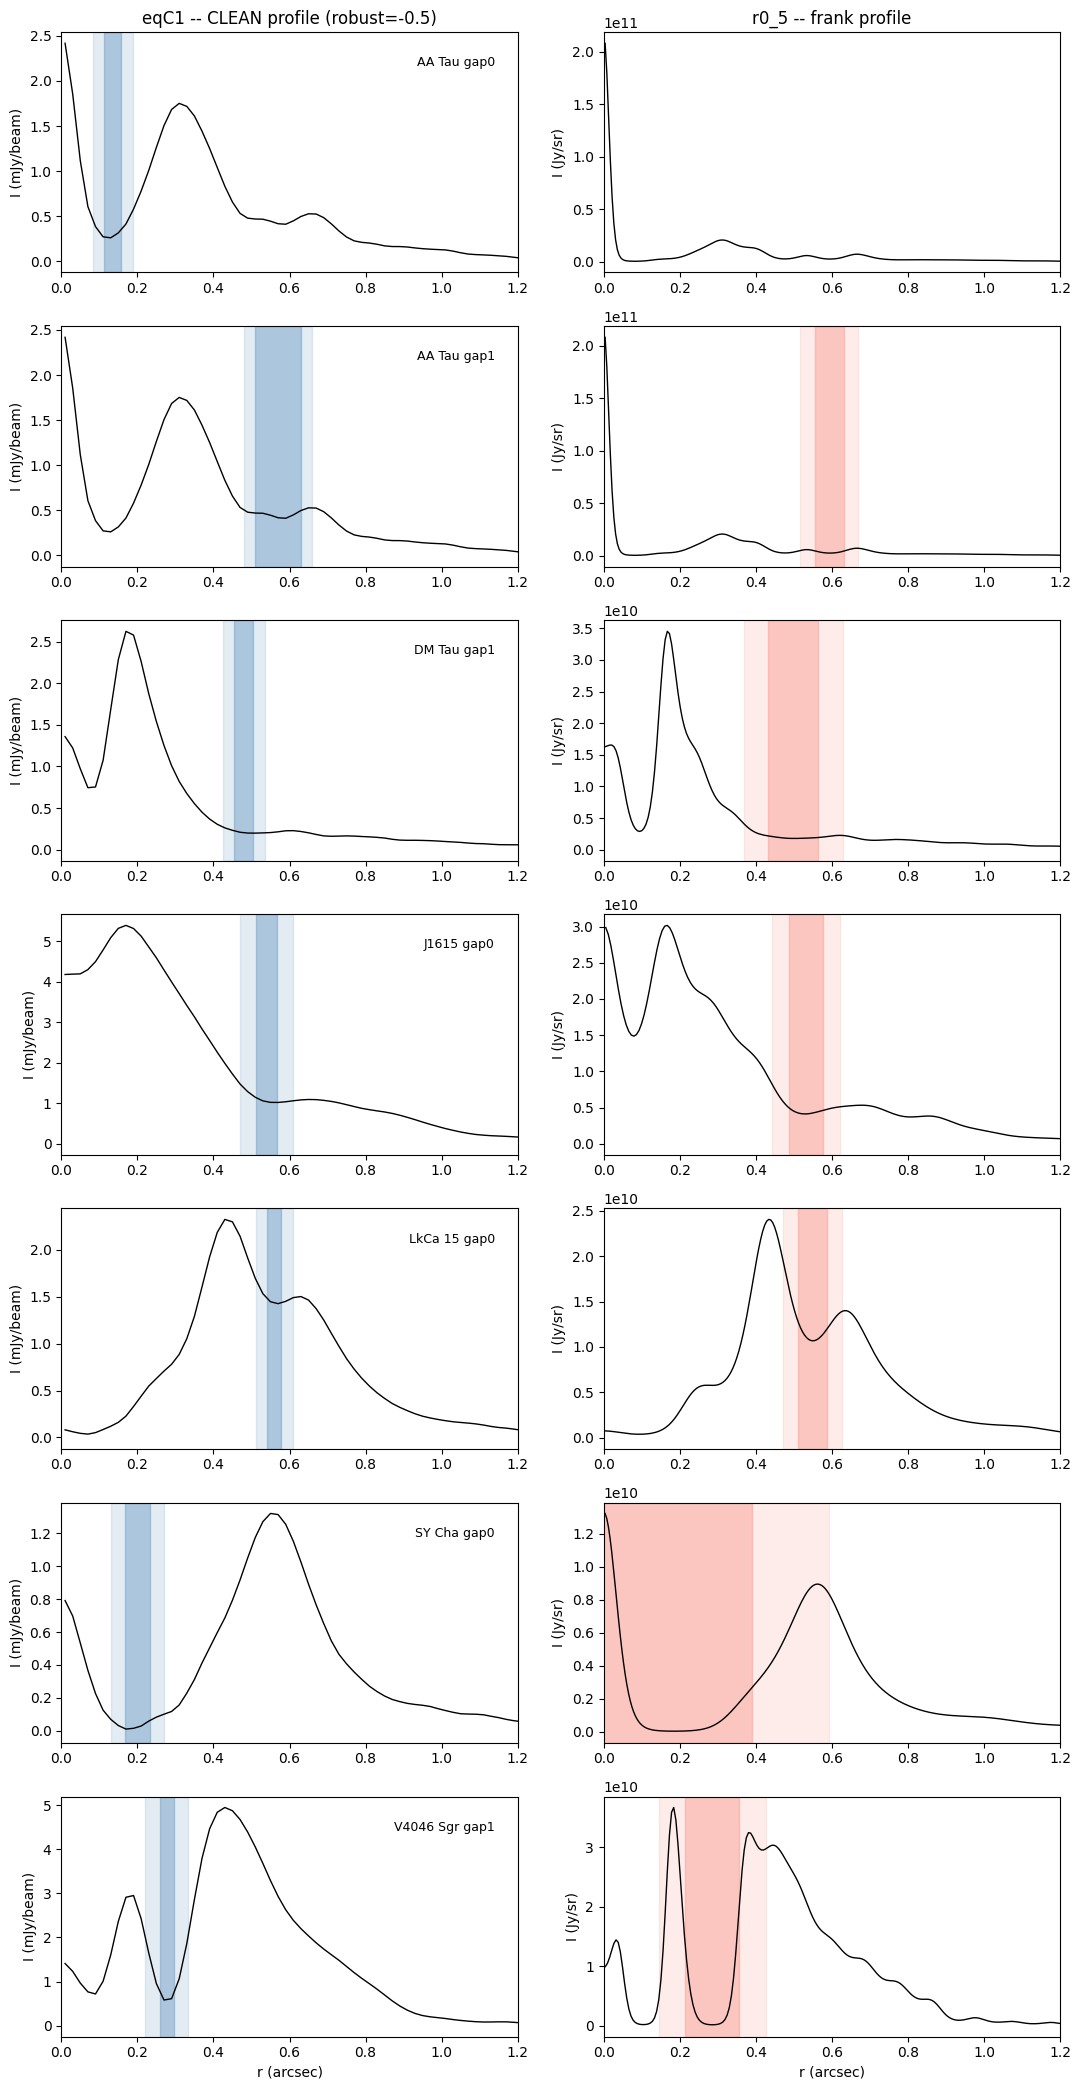

In [37]:
import sys as _sys
_sys.path.append(r"D:\CPD_MPIA\HPC_scripts\Source_codes\diskdictionary_r90")
import diskdictionaryr0_5 as diskr05

fig, axes = plt.subplots(len(Gap), 2, figsize=(11, 3 * len(Gap)))
for row, name in enumerate(Gap):
    target, gap_ix = name.rsplit("_gap", 1)
    gap_ix = int(gap_ix)

    clean_prof = np.loadtxt(rf"D:\exoALMA_disk_data\{target}\{target}_CLEAN_profile_robust-05.txt", comments="#")
    frank_prof = np.loadtxt(rf"D:\exoALMA_disk_data\{target}\{target}_frank_profile.txt", comments="#")

    rgap_eq, wgap_eq = diskdict.disk[target]["rgap"][gap_ix], diskdict.disk[target]["wgap"][gap_ix]
    f = sorted(glob.glob(f"{base_dir}/gap/{name}/recoveries/*.resid.fits"))[0]
    hd = fits.open(f)[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])
    search_eq = 0.5 * wgap_eq + 0.5 * beam_fwhm

    ax = axes[row, 0]
    ax.plot(clean_prof[:, 0], clean_prof[:, 2], "k-", lw=1)
    ax.axvspan(rgap_eq - search_eq, rgap_eq + search_eq, color="steelblue", alpha=0.15)
    ax.axvspan(rgap_eq - 0.5 * wgap_eq, rgap_eq + 0.5 * wgap_eq, color="steelblue", alpha=0.35)
    ax.set_xlim(0, 1.2)
    ax.set_ylabel("I (mJy/beam)")
    ax.text(0.95, 0.9, f"{target.replace('_', ' ')} gap{gap_ix}", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    ax = axes[row, 1]
    ax.plot(frank_prof[:, 0], frank_prof[:, 2], "k-", lw=1)
    r0_5_name = r0_5_map.get(name)
    if r0_5_name:
        r0_5_gap_ix = int(r0_5_name.rsplit("_gap", 1)[1])
        rgap_r05, wgap_r05 = diskr05.disk[target]["rgap"][r0_5_gap_ix], diskr05.disk[target]["wgap"][r0_5_gap_ix]
        ax.axvspan(rgap_r05 - wgap_r05, rgap_r05 + wgap_r05, color="salmon", alpha=0.15)
        ax.axvspan(rgap_r05 - 0.5 * wgap_r05, rgap_r05 + 0.5 * wgap_r05, color="salmon", alpha=0.35)
    ax.set_xlim(0, 1.2)
    ax.set_ylabel("I (Jy/sr)")

axes[0, 0].set_title("eqC1 -- CLEAN profile (robust=-0.5)")
axes[0, 1].set_title("r0_5 -- frank profile")
for ax in axes[-1]:
    ax.set_xlabel("r (arcsec)")
fig.tight_layout()
plt.show()

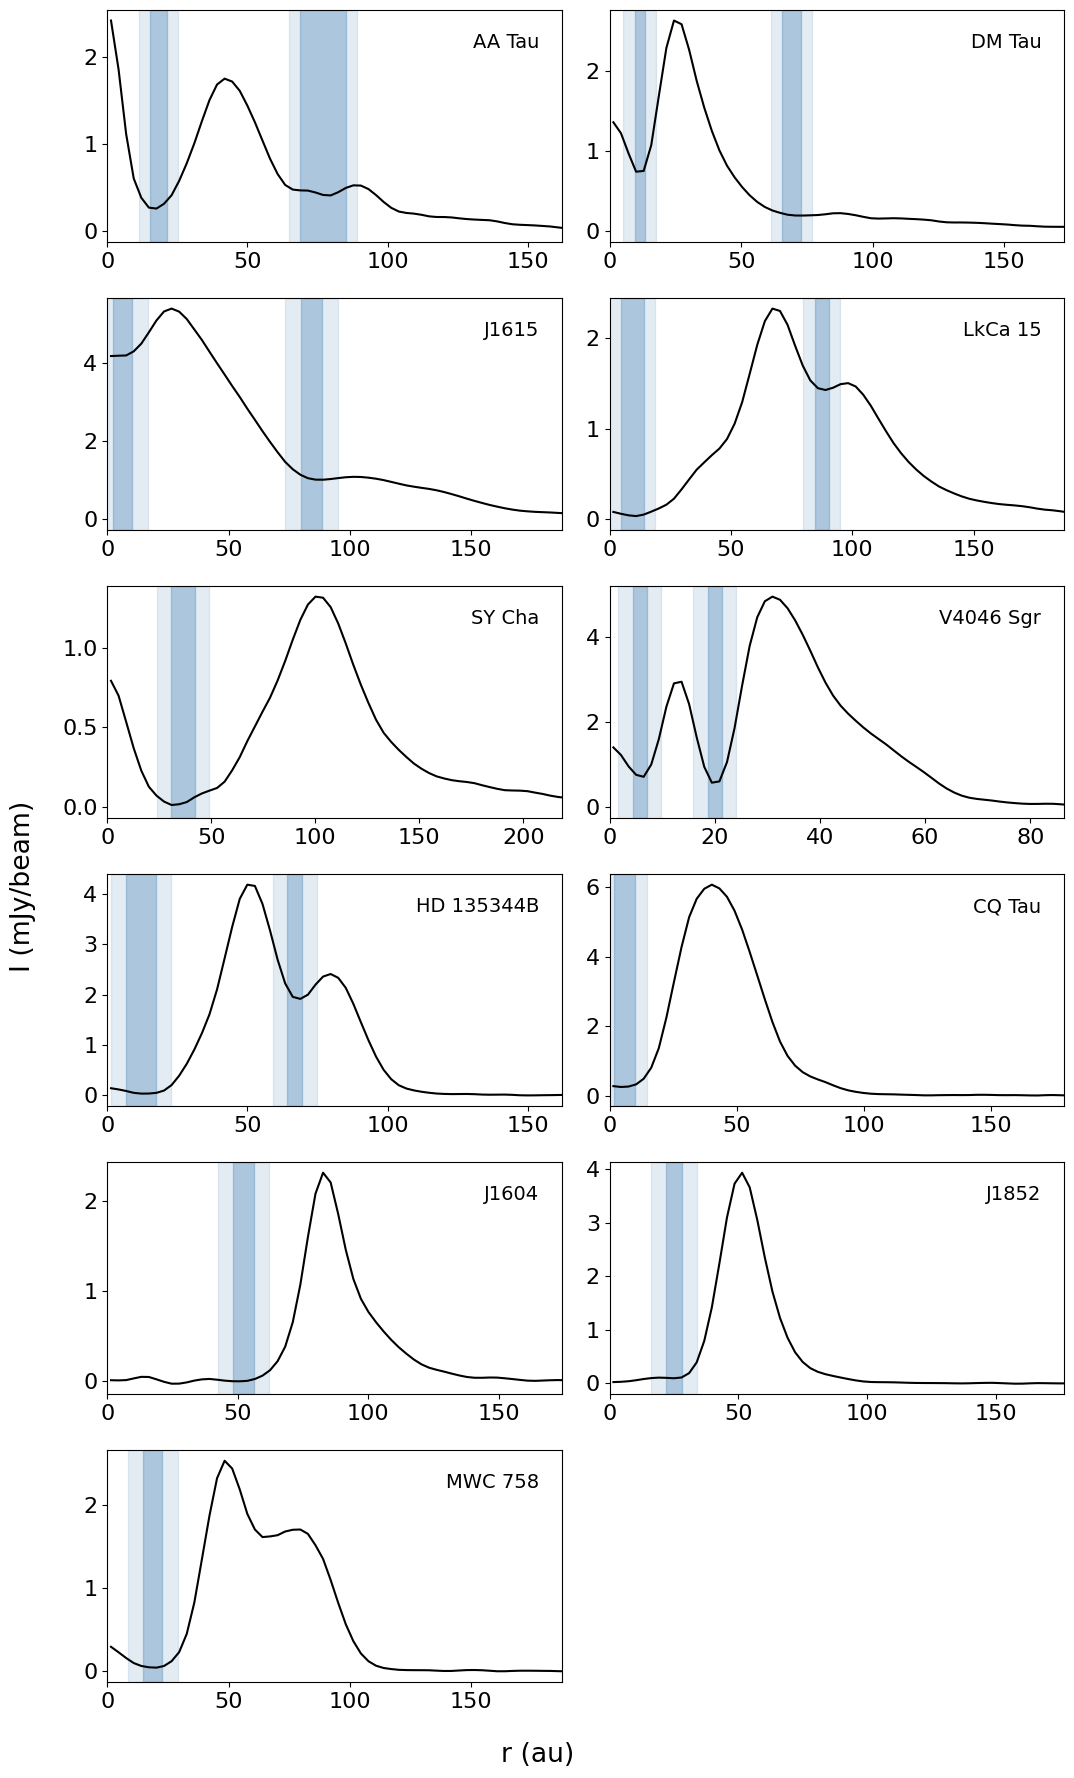

In [57]:
# 4 row x 3 column: eqC1 CLEAN (robust=-0.5) profile only, x-axis in au,
# one panel per disk across ALL gaps+inner_cavities (AllGaps, 11 disks --
# gaps in the same disk share a panel, e.g. AA_Tau/DM_Tau/HD_135344B/
# J1615/LkCa_15/V4046_Sgr each have 2), all eqC1 gap locations shaded steelblue
plt.rcParams.update({'font.size': 16})
disks_all_gap = {}
for name, sub in AllGaps:
    target = name.rsplit("_gap", 1)[0]
    disks_all_gap.setdefault(target, []).append((name, sub))

fig, axes = plt.subplots(6, 2, figsize=(11, 18))
for ax, (target, entries) in zip(axes.flat, disks_all_gap.items()):
    distance = diskdict.disk[target]["distance"]
    clean_prof = np.loadtxt(rf"D:\exoALMA_disk_data\{target}\{target}_CLEAN_profile_robust-05.txt", comments="#")
    r_au = clean_prof[:, 0] * distance

    ax.plot(r_au, clean_prof[:, 2], "k-", lw=1.5)

    name0, sub0 = entries[0]
    f = sorted(glob.glob(f"{base_dir}/{sub0}/{name0}/recoveries/*.resid.fits"))[0]
    hd = fits.open(f)[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])

    for name, sub in entries:
        gap_ix = int(name.rsplit("_gap", 1)[1])
        rgap_eq, wgap_eq = diskdict.disk[target]["rgap"][gap_ix], diskdict.disk[target]["wgap"][gap_ix]
        search_eq = 0.5 * wgap_eq + 0.5 * beam_fwhm
        rgap_au, search_au, halfwidth_au = rgap_eq * distance, search_eq * distance, 0.5 * wgap_eq * distance
        ax.axvspan(rgap_au - search_au, rgap_au + search_au, color="steelblue", alpha=0.15)
        ax.axvspan(rgap_au - halfwidth_au, rgap_au + halfwidth_au, color="steelblue", alpha=0.35)

    ax.set_xlim(0, 1.2 * distance)
    ax.text(0.95, 0.9, target.replace("_", " "), transform=ax.transAxes, ha="right", va="top", fontsize=14)

for ax in axes.flat[len(disks_all_gap):]:
    ax.axis("off")

fig.supxlabel("r (au)")
fig.supylabel("I (mJy/beam)")
#fig.suptitle("eqC1 gaps + inner cavities -- CLEAN (robust=-0.5) profile")
fig.tight_layout()
plt.show()

In [39]:
# ask about which one specifically fro comparision, but this is low priority job

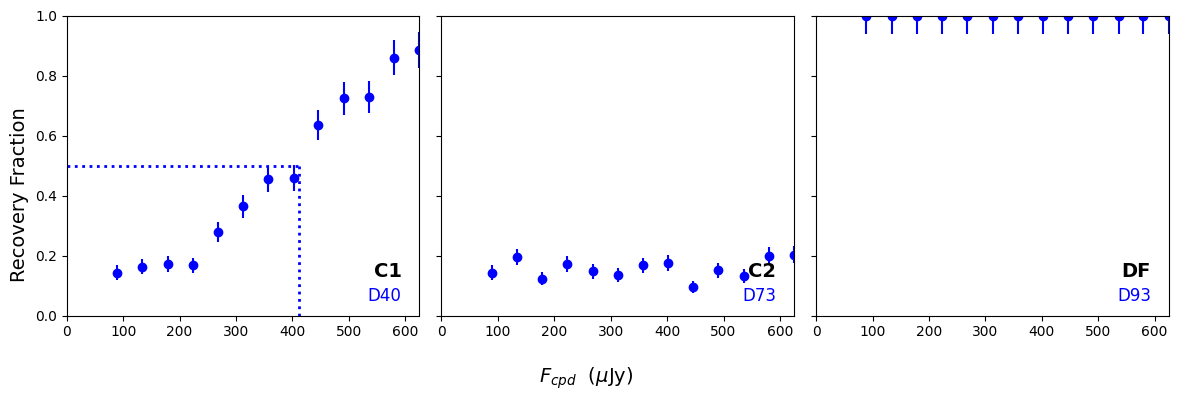

In [40]:
Candidates = [
    ("HD_135344B_C1", "HD_135344B_gap2", 0.30, 36.0),
    ("HD_135344B_C2", "HD_135344B_gap3", 0.54, 15.0),
    ("HD_135344B_DF", "HD_135344B_gap4", 0.69, -133.0),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (folder, prefix, R, az) in zip(axes, Candidates):
    D_au = R * diskdict.disk["HD_135344B"]["distance"]
    Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{base_dir}/gap/{folder}/recoveries/{prefix}_rprofs.combined.txt").T
    ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="b", ls="none", capsize=0.0, elinewidth=1.5)
    if frec_B[0] < 0.5 and frec_B.max() >= 0.5:   # only a genuine 50% crossing
        F50 = f50(Fcpd, frec_B)
        ax.hlines(0.5, 0, F50, color="b", ls=":", lw=2, alpha=1)
        ax.vlines(F50, 0, 0.5, color="b", ls=":", lw=2, alpha=1)
    ax.text(0.95, 0.13, folder.split("_")[-1], transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
    ax.text(0.95, 0.05, f"D{D_au:.0f}", color="b", transform=ax.transAxes, ha="right", fontsize=12)
    ax.set_xlim(0, np.max(Fcpd))
    ax.set_ylim(0, 1)
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=14)
fig.supylabel("Recovery Fraction", fontsize=14)
fig.tight_layout()
plt.show()

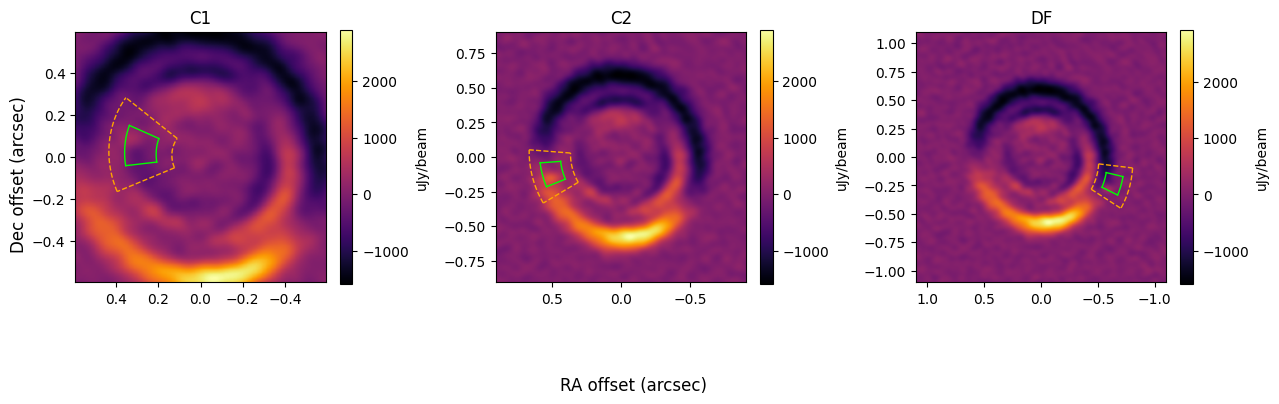

In [41]:
def box_outline(r_lo, r_hi, az_lo, az_hi, PAr, inclr, n=50):
    az_arc = np.radians(np.linspace(az_lo, az_hi, n))
    x1, y1 = polar_to_sky(r_lo, az_arc, PAr, inclr)
    x2, y2 = polar_to_sky(r_hi, az_arc, PAr, inclr)
    x3, y3 = polar_to_sky(np.array([r_lo, r_hi]), np.radians(az_lo), PAr, inclr)
    x4, y4 = polar_to_sky(np.array([r_lo, r_hi]), np.radians(az_hi), PAr, inclr)
    return x1, y1, x2, y2, x3, y3, x4, y4

PAr = np.radians(diskdict.disk["HD_135344B"]["PA"])
inclr = np.radians(diskdict.disk["HD_135344B"]["incl"])
dx, dy = diskdict.disk["HD_135344B"]["dx"], diskdict.disk["HD_135344B"]["dy"]
BEAM_FWHM = 0.0786

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (folder, prefix, R, az) in zip(axes, Candidates):
    inj_r_hw = BEAM_FWHM
    inj_az_hw = np.degrees(BEAM_FWHM / R)
    search_r_hw = 2 * BEAM_FWHM
    search_az_hw = np.degrees(search_r_hw / R)

    f = sorted(glob.glob(f"{base_dir}/gap/{folder}/recoveries/*.resid.fits"))[0]
    hdu = fits.open(f)
    img = 1e6 * np.squeeze(hdu[0].data)
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - dx, RAo[-1] - dx, DECo[0] - dy, DECo[-1] - dy]

    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    plt.colorbar(im, ax=ax, fraction=0.046, label="uJy/beam")

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - inj_r_hw, R + inj_r_hw, az - inj_az_hw, az + inj_az_hw, PAr, inclr)
    ax.plot(x1, y1, color="lime", lw=1)
    ax.plot(x2, y2, color="lime", lw=1)
    ax.plot(x3, y3, color="lime", lw=1)
    ax.plot(x4, y4, color="lime", lw=1)

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - search_r_hw, R + search_r_hw, az - search_az_hw, az + search_az_hw, PAr, inclr)
    ax.plot(x1, y1, color="orange", ls="--", lw=1)
    ax.plot(x2, y2, color="orange", ls="--", lw=1)
    ax.plot(x3, y3, color="orange", ls="--", lw=1)
    ax.plot(x4, y4, color="orange", ls="--", lw=1)

    zoom = 1.3 * (R + search_r_hw)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.set_title(folder.split("_")[-1])

fig.supxlabel("RA offset (arcsec)")
fig.supylabel("Dec offset (arcsec)")
fig.tight_layout()
plt.show()

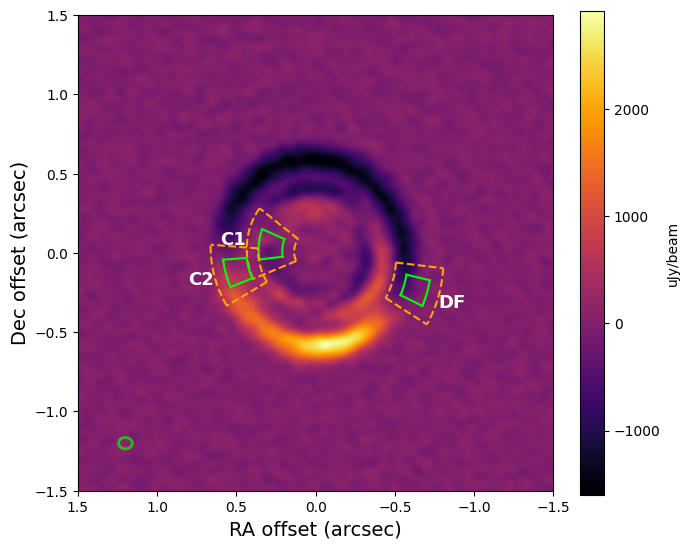

In [42]:
from matplotlib.patches import Ellipse

# all 3 candidates' injection/search boxes on ONE zoomed-out (+/-2") view of
# the same disk residual, labeled C1/C2/DF -- companion to the per-candidate
# zoomed-in grid above. Self-contained (own PAr/incl/dx/dy/img names) so it
# doesn't collide with the same-named variables reused in other cells.
_PAr = np.radians(diskdict.disk["HD_135344B"]["PA"])
_inclr = np.radians(diskdict.disk["HD_135344B"]["incl"])
_dx = diskdict.disk["HD_135344B"]["dx"]
_dy = diskdict.disk["HD_135344B"]["dy"]

_folder0 = Candidates[0][0]
_f = sorted(glob.glob(f"{base_dir}/gap/{_folder0}/recoveries/*.resid.fits"))[0]
_hdu = fits.open(_f)
_img = 1e6 * np.squeeze(_hdu[0].data)
_hd = _hdu[0].header
_nx, _ny = _hd["NAXIS1"], _hd["NAXIS2"]
_RAo = 3600 * _hd["CDELT1"] * (np.arange(_nx) - (_hd["CRPIX1"] - 1))
_DECo = 3600 * _hd["CDELT2"] * (np.arange(_ny) - (_hd["CRPIX2"] - 1))
_extent = [_RAo[0] - _dx, _RAo[-1] - _dx, _DECo[0] - _dy, _DECo[-1] - _dy]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(_img, origin="lower", cmap="inferno", extent=_extent)
plt.colorbar(im, ax=ax, fraction=0.046, label="uJy/beam")

for folder, prefix, R, az in Candidates:
    inj_r_hw = BEAM_FWHM
    inj_az_hw = np.degrees(BEAM_FWHM / R)
    search_r_hw = 2 * BEAM_FWHM
    search_az_hw = np.degrees(search_r_hw / R)

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - inj_r_hw, R + inj_r_hw, az - inj_az_hw, az + inj_az_hw, _PAr, _inclr)
    ax.plot(x1, y1, color="lime", lw=1.5)
    ax.plot(x2, y2, color="lime", lw=1.5)
    ax.plot(x3, y3, color="lime", lw=1.5)
    ax.plot(x4, y4, color="lime", lw=1.5)

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - search_r_hw, R + search_r_hw, az - search_az_hw, az + search_az_hw, _PAr, _inclr)
    ax.plot(x1, y1, color="orange", ls="--", lw=1.5)
    ax.plot(x2, y2, color="orange", ls="--", lw=1.5)
    ax.plot(x3, y3, color="orange", ls="--", lw=1.5)
    ax.plot(x4, y4, color="orange", ls="--", lw=1.5)

    label_x, label_y = polar_to_sky(R + 1.6 * search_r_hw, np.radians(az), _PAr, _inclr)
    ax.text(label_x, label_y, folder.split("_")[-1], color="white", fontsize=13,
            fontweight="bold", ha="center", va="center")

# beam ellipse, lower-left corner (RA axis is flipped, so "lower left" = +RA, -Dec)
_beam_maj = 3600 * _hd["BMAJ"]
_beam_min = 3600 * _hd["BMIN"]
_beam_pa = _hd["BPA"]
ax.add_patch(Ellipse((1.2, -1.2), _beam_min, _beam_maj, angle=-_beam_pa,
                      facecolor="none", edgecolor="lime", lw=2, alpha=0.7, zorder=6))

ax.set_xlim(1.5, -1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("RA offset (arcsec)", fontsize=14)
ax.set_ylabel("Dec offset (arcsec)", fontsize=14)
fig.tight_layout()
plt.show()

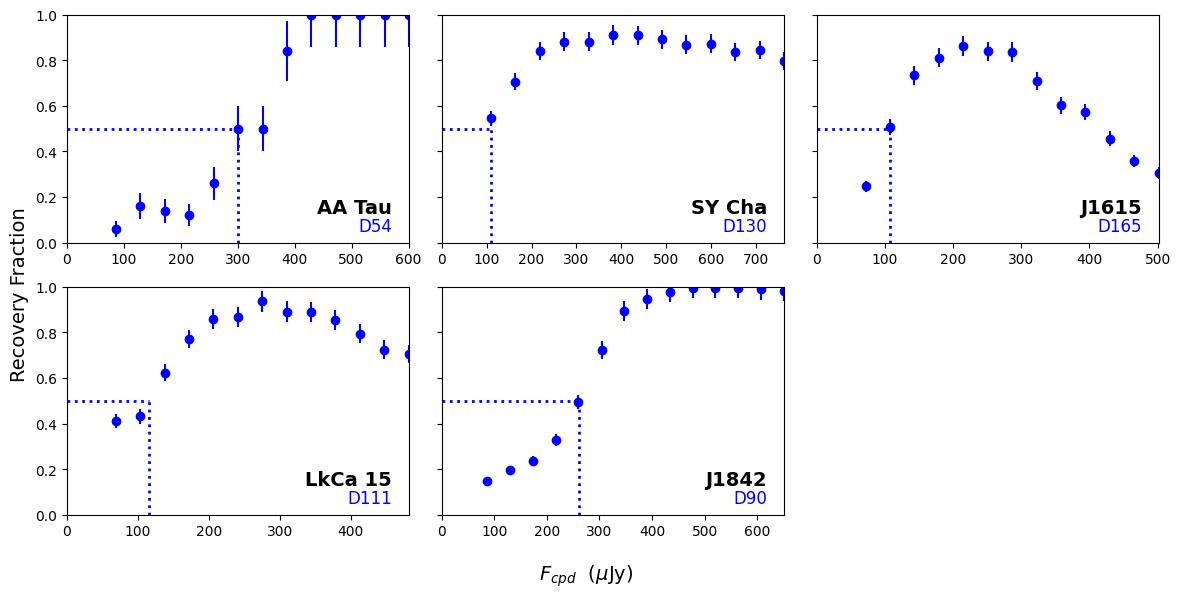

In [43]:
Kink = [
    ("AA_Tau_kink0",  "AA_Tau",  2),
    ("SY_Cha_kink0",  "SY_Cha",  1),
    ("J1615_kink0",   "J1615",   2),
    ("LkCa_15_kink0", "LkCa_15", 2),
    ("J1842_kink0",   "J1842",   0),
]
kink_base_dir = r"D:\CPD_MPIA\HPC_kink"

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    D_au = diskdict.disk[target]["rgap"][ix] * diskdict.disk[target]["distance"]
    Fcpd, _, _, _, frec_B, efrec_B, _ = np.loadtxt(f"{kink_base_dir}/{folder}/recoveries/{target}_gap{ix}_rprofs.combined.txt").T
    ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="b", ls="none", capsize=0.0, elinewidth=1.5)
    F50 = f50(Fcpd, frec_B)
    ax.hlines(0.5, 0, F50, color="b", ls=":", lw=2, alpha=1)
    ax.vlines(F50, 0, 0.5, color="b", ls=":", lw=2, alpha=1)
    ax.text(0.95, 0.13, target.replace("_", " "), transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
    ax.text(0.95, 0.05, f"D{D_au:.0f}", color="b", transform=ax.transAxes, ha="right", fontsize=12)
    ax.set_xlim(0, np.max(Fcpd))
    ax.set_ylim(0, 1)

for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=14)
fig.supylabel("Recovery Fraction", fontsize=14)
fig.tight_layout()
plt.show()

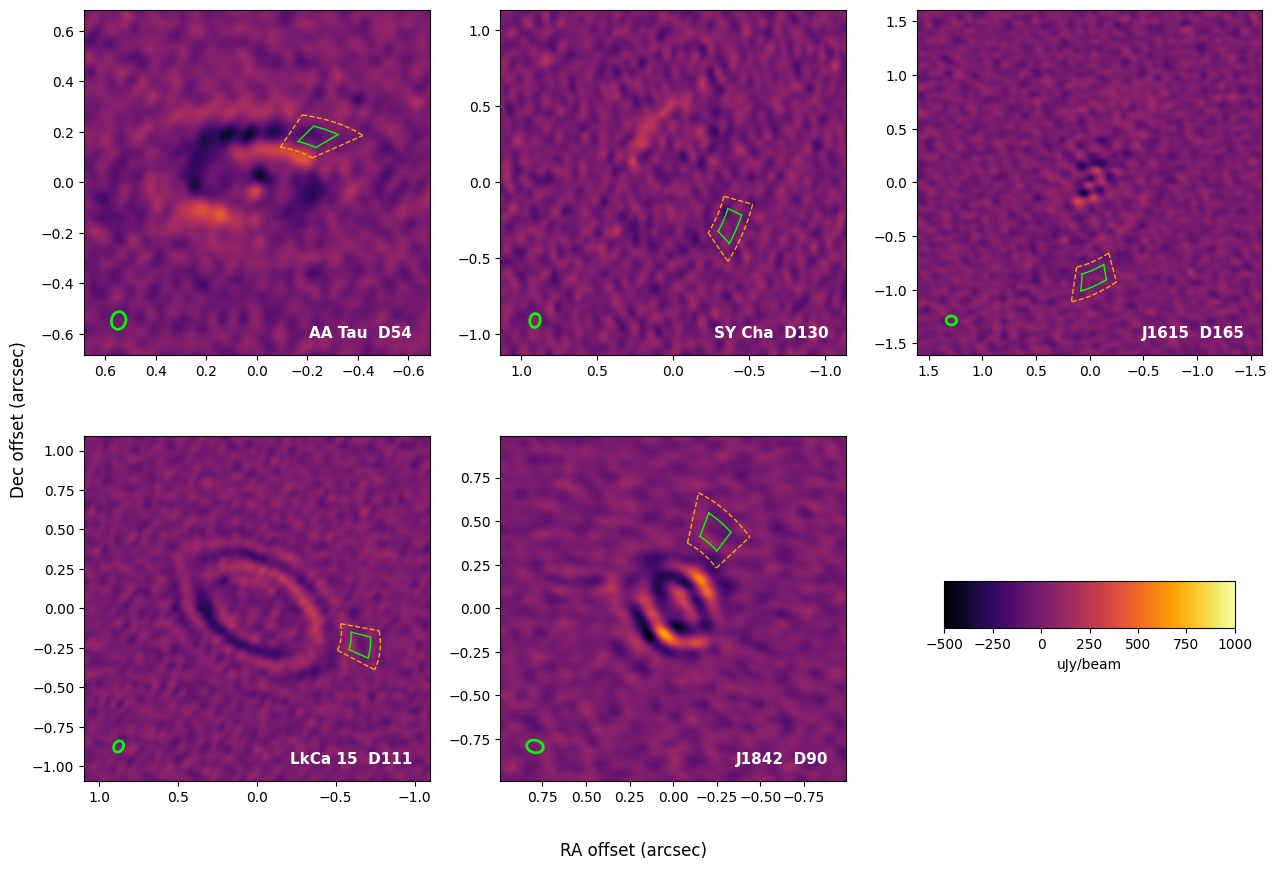

In [44]:
from matplotlib.patches import Ellipse

kink_geom = {
    "AA_Tau":  dict(R=0.3994, AZ=-141.45, BEAM=0.0632),
    "SY_Cha":  dict(R=0.7167, AZ=14.58,   BEAM=0.0791),
    "J1615":   dict(R=1.0582, AZ=43.01,   BEAM=0.0900),
    "LkCa_15": dict(R=0.7093, AZ=-104.29, BEAM=0.0664),
    "J1842":   dict(R=0.5961, AZ=151.47,  BEAM=0.0831),
}
KINK_AZ_HALFWIDTH = 7.5   # deg, fixed wedge used for injection (not beam-arc-derived)
VMIN, VMAX = -500, 1000    # common color scale across all 5 disks

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    g = kink_geom[target]
    R, AZ, BEAM = g["R"], g["AZ"], g["BEAM"]
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])
    dx, dy = diskdict.disk[target]["dx"], diskdict.disk[target]["dy"]
    D_au = R * diskdict.disk[target]["distance"]

    inj_r_hw = BEAM
    inj_az_hw = KINK_AZ_HALFWIDTH
    search_r_hw = 2 * BEAM
    search_az_hw = KINK_AZ_HALFWIDTH + np.degrees(BEAM / R)

    # real (not injected) frank-residual image, robust=-0.5 -- same imaging
    # convention as the injection-recovery pipeline, just without a fake source
    f = rf"D:\exoALMA_disk_data\{target}\images_frank_residuals_different_robust\{target}_continuum_resid_robust-0.5.image.fits"
    hdu = fits.open(f)
    img = 1e6 * np.squeeze(hdu[0].data)
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - dx, RAo[-1] - dx, DECo[0] - dy, DECo[-1] - dy]

    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent, vmin=VMIN, vmax=VMAX)

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - inj_r_hw, R + inj_r_hw, AZ - inj_az_hw, AZ + inj_az_hw, PAr, inclr)
    ax.plot(x1, y1, color="lime", lw=1)
    ax.plot(x2, y2, color="lime", lw=1)
    ax.plot(x3, y3, color="lime", lw=1)
    ax.plot(x4, y4, color="lime", lw=1, label="injection zone")

    x1, y1, x2, y2, x3, y3, x4, y4 = box_outline(R - search_r_hw, R + search_r_hw, AZ - search_az_hw, AZ + search_az_hw, PAr, inclr)
    ax.plot(x1, y1, color="orange", ls="--", lw=1)
    ax.plot(x2, y2, color="orange", ls="--", lw=1)
    ax.plot(x3, y3, color="orange", ls="--", lw=1)
    ax.plot(x4, y4, color="orange", ls="--", lw=1, label="search box")

    zoom = 1.3 * (R + search_r_hw)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)

    beam_maj = 3600 * hd["BMAJ"]
    beam_min = 3600 * hd["BMIN"]
    beam_pa = hd["BPA"]
    ax.add_patch(Ellipse((0.8 * zoom, -0.8 * zoom), beam_min, beam_maj, angle=-beam_pa,
                          facecolor="none", edgecolor="lime", lw=2,zorder=6))

    ax.text(0.95, 0.05, f"{target.replace('_', ' ')}  D{D_au:.0f}", transform=ax.transAxes,
            ha="right", color="white", fontsize=11, fontweight="bold")
    #ax.legend(fontsize=8, loc="upper right")

empty_ax = axes.flat[len(Kink)]
empty_ax.axis("off")
cax = empty_ax.inset_axes([0.08, 0.45, 0.84, 0.12])
fig.colorbar(im, cax=cax, orientation="horizontal", label="uJy/beam")

for ax in axes.flat[len(Kink) + 1:]:
    ax.axis("off")
fig.supxlabel("RA offset (arcsec)")
fig.supylabel("Dec offset (arcsec)")
fig.tight_layout()
plt.show()

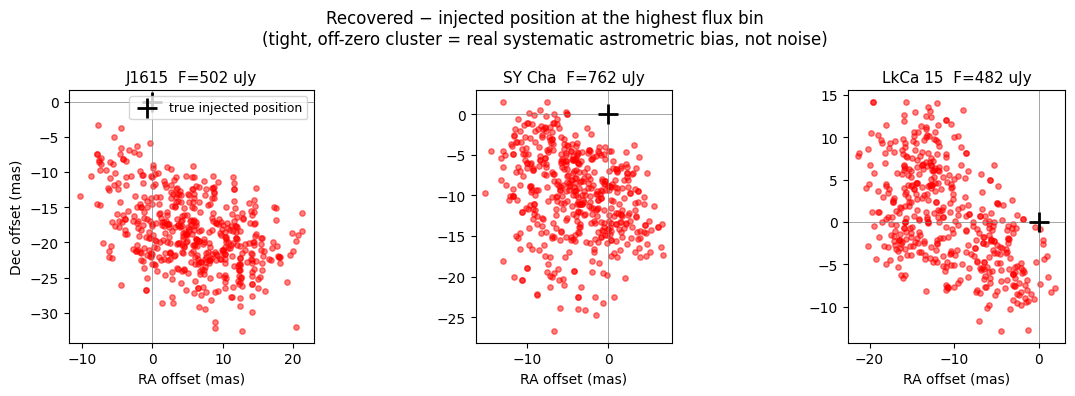

In [45]:
bias_disks = [("J1615_kink0", "J1615", 2), ("SY_Cha_kink0", "SY_Cha", 1), ("LkCa_15_kink0", "LkCa_15", 2)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (folder, target, ix) in zip(axes, bias_disks):
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])

    files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T
    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)

    fmax = Fi.max()
    m = Fi == fmax
    dx, dy = 1000 * (xr[m] - xi[m]), 1000 * (yr[m] - yi[m])   # mas

    ax.scatter(dx, dy, s=15, alpha=0.5, color="r")
    ax.scatter(0, 0, marker="+", s=200, color="k", linewidths=2, zorder=5, label="true injected position")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_aspect("equal")
    ax.set_title(f"{target.replace('_', ' ')}  F={fmax:.0f} uJy", fontsize=11)
    ax.set_xlabel("RA offset (mas)")

axes[0].set_ylabel("Dec offset (mas)")
axes[0].legend(fontsize=9, loc="upper right")
fig.suptitle("Recovered − injected position at the highest flux bin\n(tight, off-zero cluster = real systematic astrometric bias, not noise)")
fig.tight_layout()
plt.show()

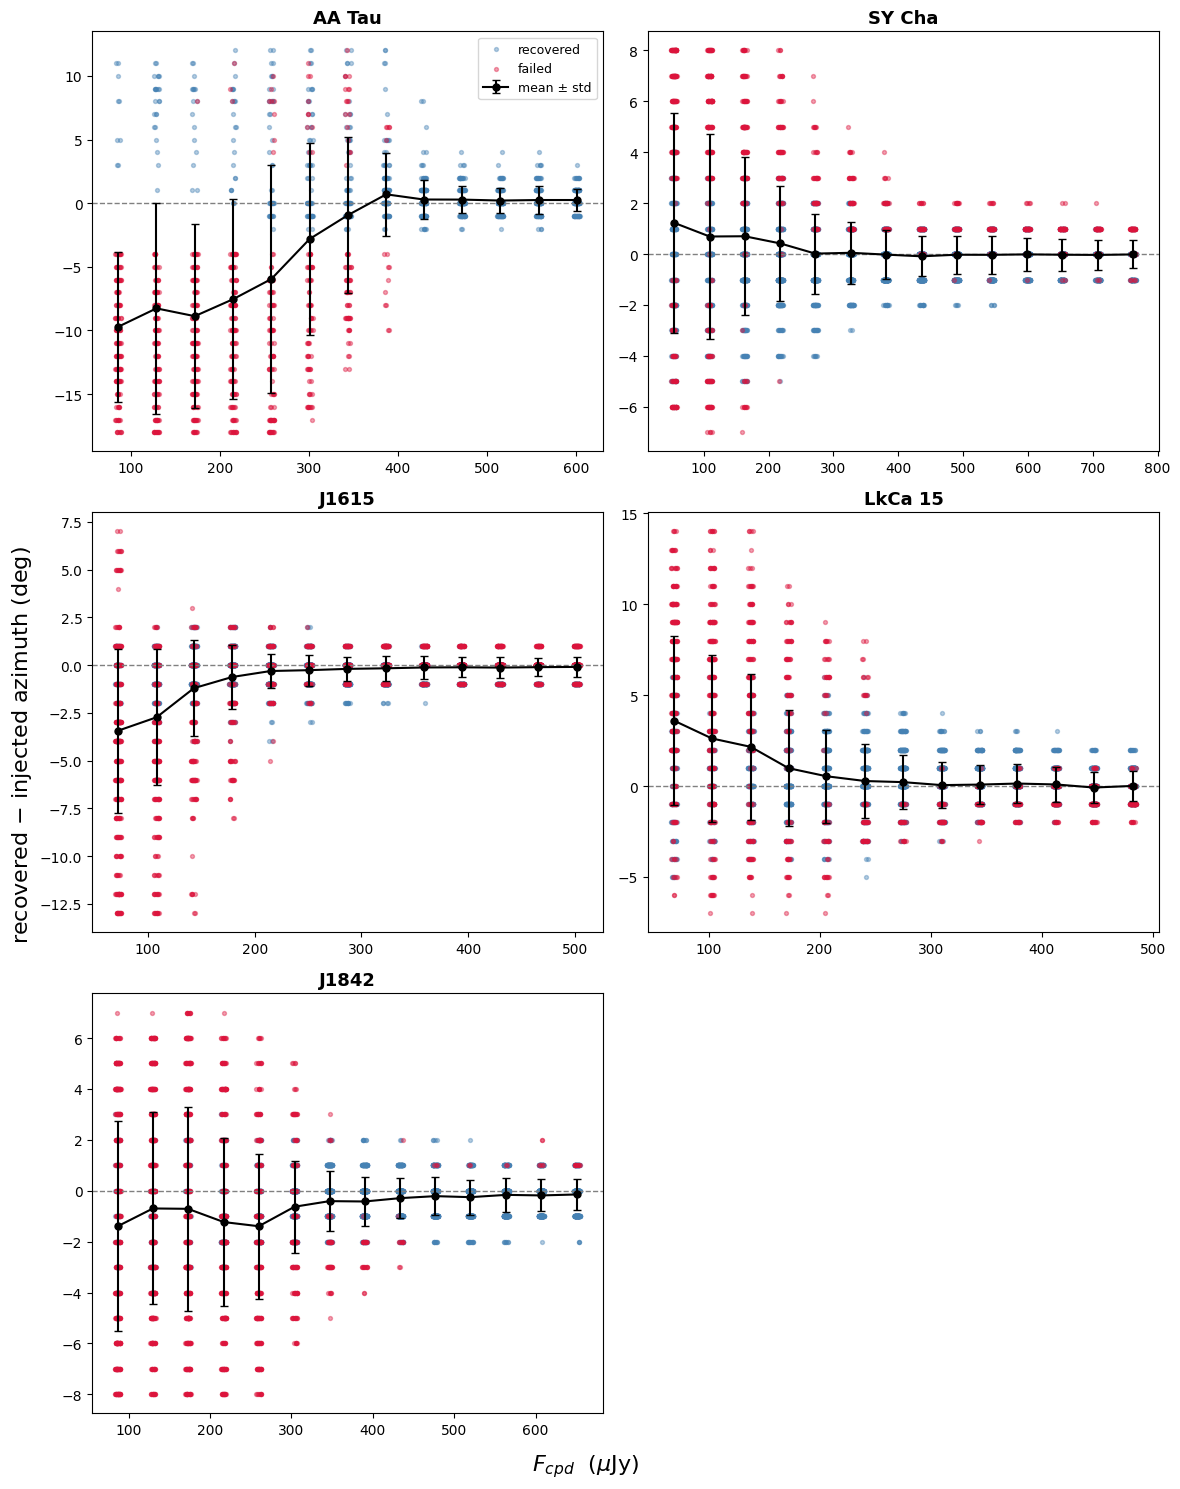

In [46]:
# scatter: injected flux vs. azimuthal offset (az_recovered - az_injected), all
# flux bins at once, for each kink disk -- same template as the radial-offset
# check used in HPC_eqC1_gap/gap/AA_Tau_gap0/assess_recovery.ipynb, swapped to azimuth.
# recovered/failed uses Criterion B (ALMA Cycle 7 Handbook) -- the same criterion
# the official *_rprofs.combined.txt / frec_B curves use.

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])

    fits_files = sorted(glob.glob(f"{kink_base_dir}/{folder}/recoveries/*.resid.fits"))
    hd = fits.open(fits_files[0])[0].header
    pix_size = np.abs(3600 * hd["CDELT2"])
    freq = hd["CRVAL3"]
    wave = 2.99792e5 / freq

    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    Bmax_km = (wave * np.sqrt(vdat["u"] ** 2 + vdat["v"] ** 2)).max()

    files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T

    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)
    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size)
    is_recovered = d_ir <= dlim_B

    daz = ((azr - azi + 180) % 360) - 180   # wrapped azimuthal offset, degrees
    Fcpd = np.unique(Fi)
    jitter = (np.random.rand(len(Fi)) - 0.5) * 0.15 * (Fcpd[1] - Fcpd[0])

    ax.scatter(Fi[is_recovered] + jitter[is_recovered], daz[is_recovered],
               s=8, color="steelblue", alpha=0.4, label="recovered")
    ax.scatter(Fi[~is_recovered] + jitter[~is_recovered], daz[~is_recovered],
               s=8, color="crimson", alpha=0.4, label="failed")

    mean_daz = np.array([np.mean(daz[Fi == Fc]) for Fc in Fcpd])
    std_daz = np.array([np.std(daz[Fi == Fc]) for Fc in Fcpd])
    ax.errorbar(Fcpd, mean_daz, yerr=std_daz, color="k", marker="o", ms=5, lw=1.5,
                capsize=3, label="mean ± std", zorder=5)

    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_title(f"{target.replace('_', ' ')}", fontsize=13, fontweight="bold")

axes.flat[0].legend(fontsize=9)
for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=16)
fig.supylabel(r"recovered $-$ injected azimuth (deg)", fontsize=16)
fig.tight_layout()
plt.show()

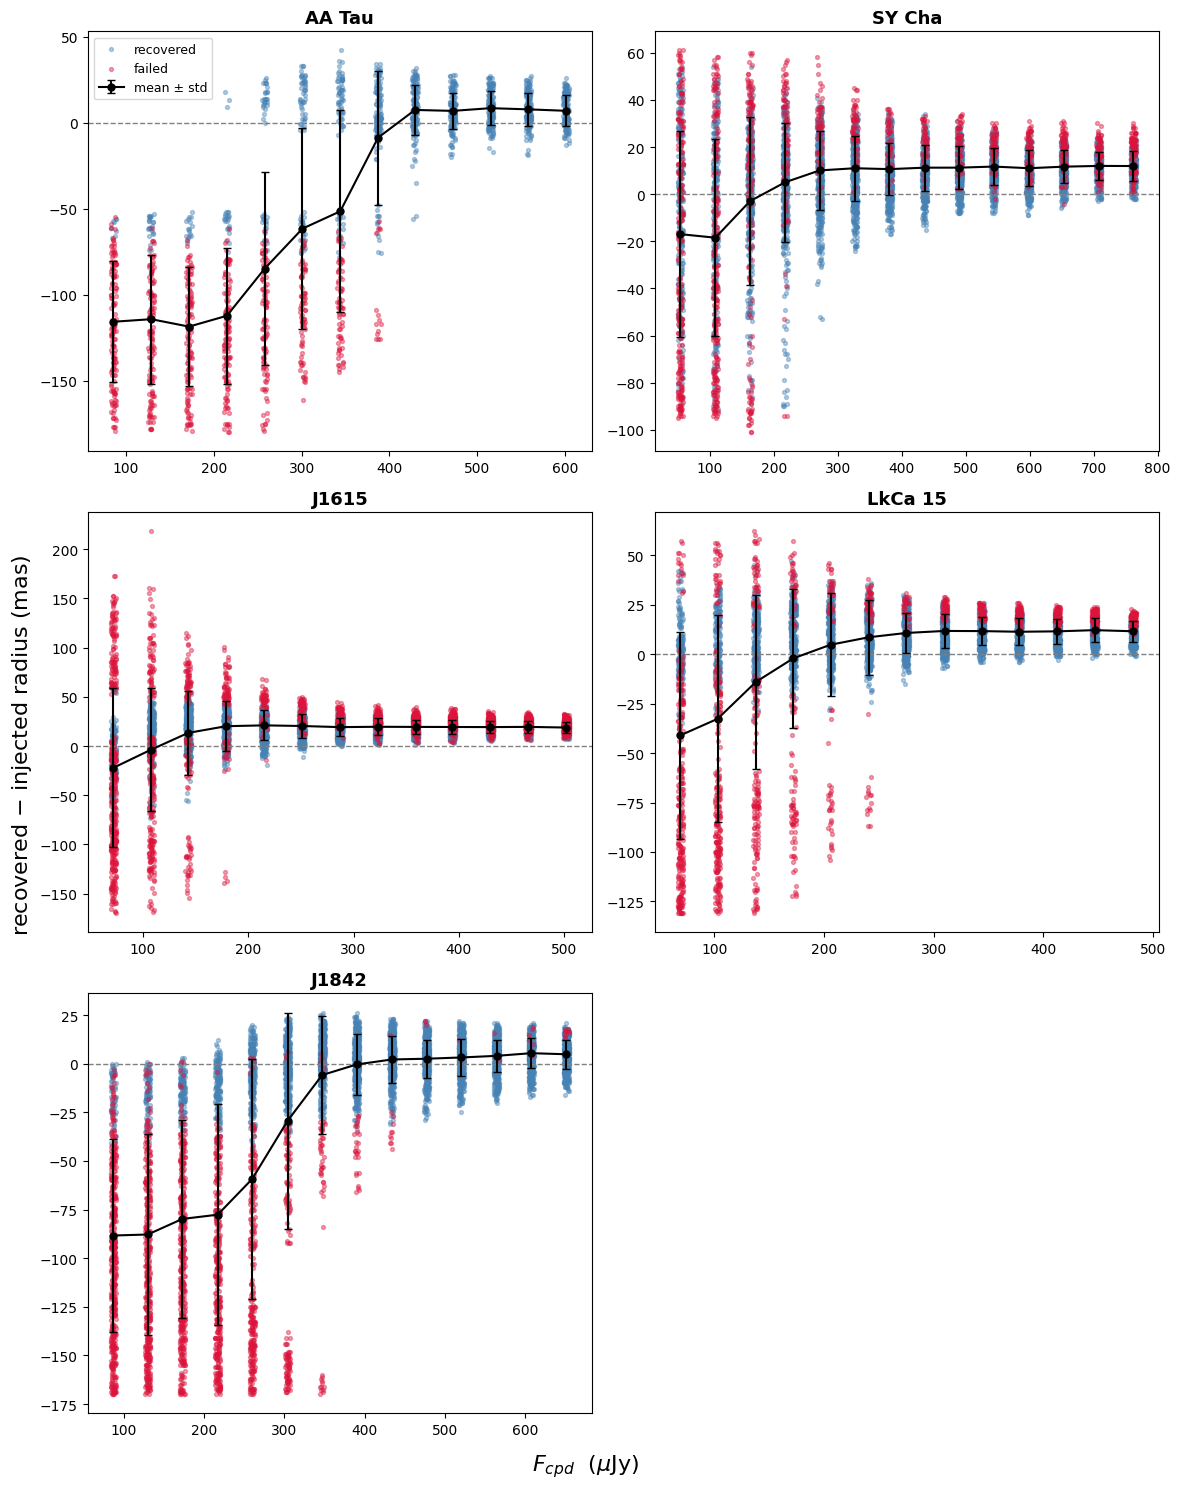

In [47]:
# same as above, but radial offset (r_recovered - r_injected) instead of azimuthal --
# this is the one that actually shows a bias: it converges to a small NONZERO
# value at high flux (same sign for every disk here), while the azimuthal one
# above converges to zero like ordinary noise.
# recovered/failed uses Criterion B (ALMA Cycle 7 Handbook) -- the same criterion
# the official *_rprofs.combined.txt / frec_B curves use.

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])

    fits_files = sorted(glob.glob(f"{kink_base_dir}/{folder}/recoveries/*.resid.fits"))
    hd = fits.open(fits_files[0])[0].header
    pix_size = np.abs(3600 * hd["CDELT2"])
    freq = hd["CRVAL3"]
    wave = 2.99792e5 / freq

    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    Bmax_km = (wave * np.sqrt(vdat["u"] ** 2 + vdat["v"] ** 2)).max()

    files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T

    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)
    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size)
    is_recovered = d_ir <= dlim_B

    dr_mas = 1000 * (rr - ri)
    Fcpd = np.unique(Fi)
    jitter = (np.random.rand(len(Fi)) - 0.5) * 0.15 * (Fcpd[1] - Fcpd[0])

    ax.scatter(Fi[is_recovered] + jitter[is_recovered], dr_mas[is_recovered],
               s=8, color="steelblue", alpha=0.4, label="recovered")
    ax.scatter(Fi[~is_recovered] + jitter[~is_recovered], dr_mas[~is_recovered],
               s=8, color="crimson", alpha=0.4, label="failed")

    mean_dr = np.array([np.mean(dr_mas[Fi == Fc]) for Fc in Fcpd])
    std_dr = np.array([np.std(dr_mas[Fi == Fc]) for Fc in Fcpd])
    ax.errorbar(Fcpd, mean_dr, yerr=std_dr, color="k", marker="o", ms=5, lw=1.5,
                capsize=3, label="mean ± std", zorder=5)

    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_title(f"{target.replace('_', ' ')}", fontsize=13, fontweight="bold")

axes.flat[0].legend(fontsize=9)
for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=16)
fig.supylabel(r"recovered $-$ injected radius (mas)", fontsize=16)
fig.tight_layout()
plt.show()

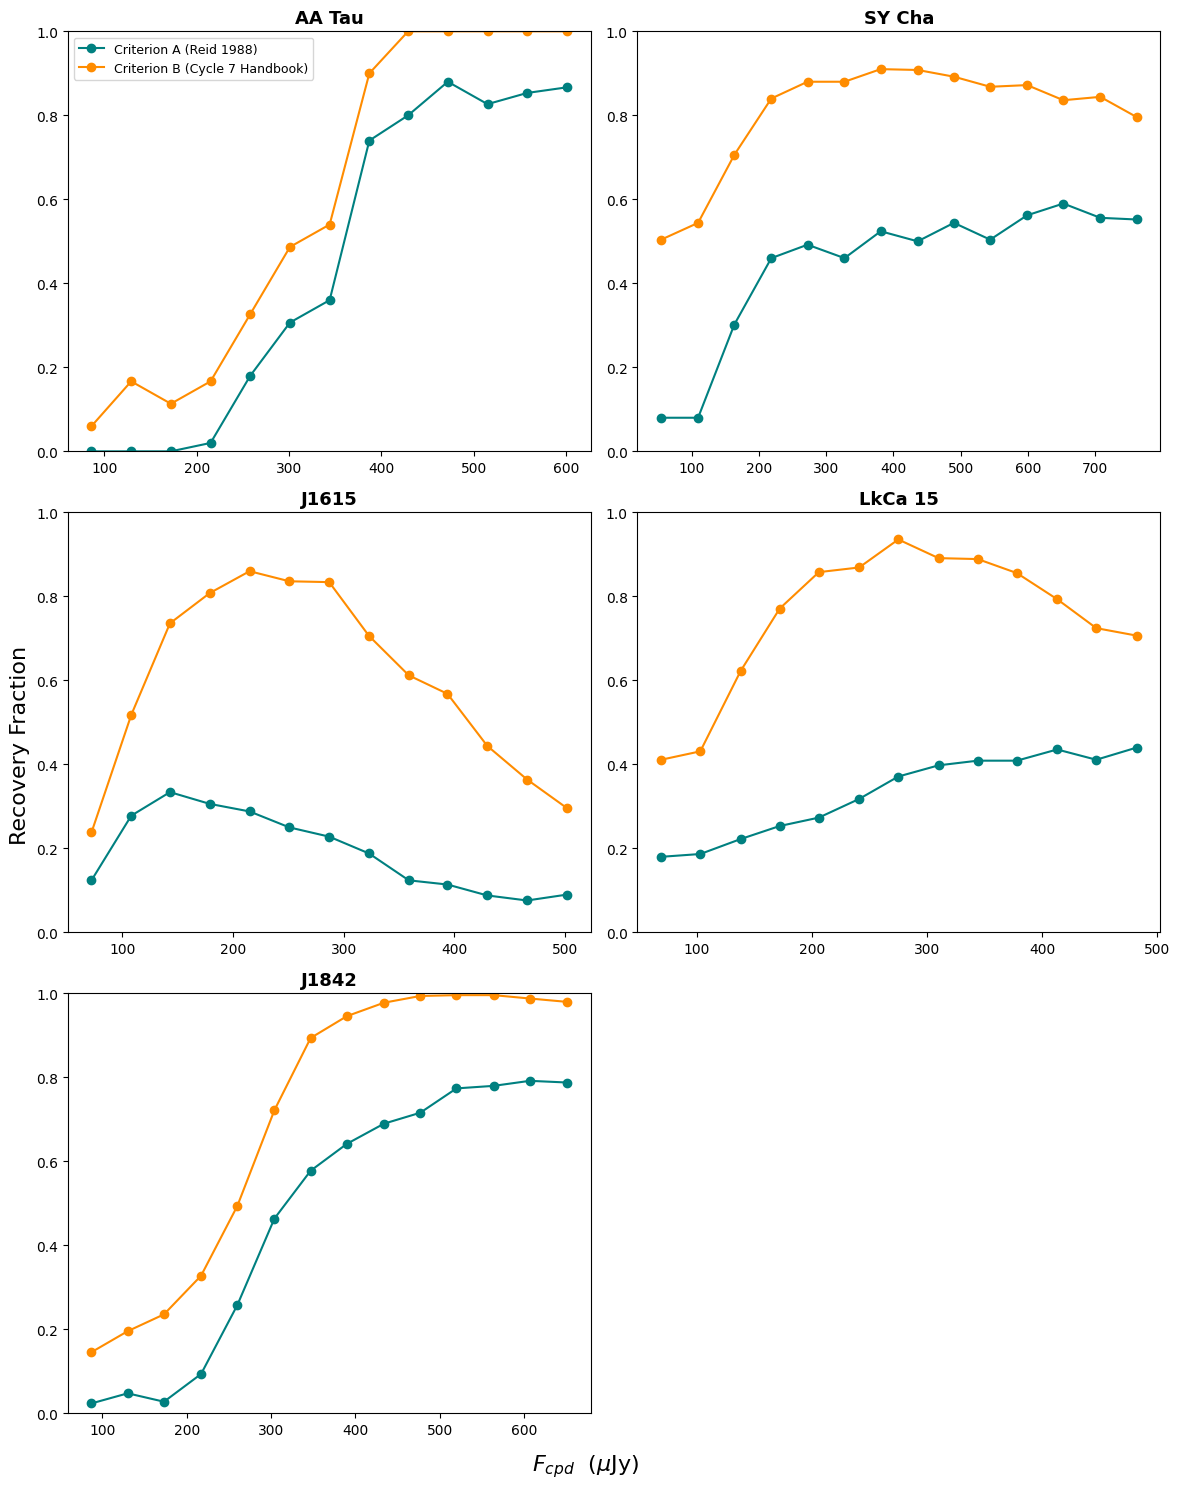

In [48]:
# Criterion A (Reid et al. 1988) vs Criterion B (ALMA Cycle 7 Handbook) side by side --
# Criterion B is what the official *_rprofs.combined.txt files (frec_B, used in every
# recovery-fraction plot above) actually use. Criterion A's tolerance hits a hard
# 2-pixel floor and stops shrinking; Criterion B's tolerance keeps shrinking with no
# floor over this flux range, which is why the two disagree at high flux.

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])

    fits_files = sorted(glob.glob(f"{kink_base_dir}/{folder}/recoveries/*.resid.fits"))
    hd = fits.open(fits_files[0])[0].header
    beam_fwhm = np.sqrt(3600 ** 2 * hd["BMAJ"] * hd["BMIN"])
    pix_size = np.abs(3600 * hd["CDELT2"])
    freq = hd["CRVAL3"]
    wave = 2.99792e5 / freq

    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    Bmax_km = (wave * np.sqrt(vdat["u"] ** 2 + vdat["v"] ** 2)).max()

    files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T

    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)

    sigma_A = (4 / np.pi) ** 0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    dlim_A = np.maximum(ast_tol * sigma_A, npix_tol * pix_size)
    is_recovered_A = d_ir <= dlim_A

    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size)
    is_recovered_B = d_ir <= dlim_B

    Fcpd = np.unique(Fi)
    frecA = np.array([is_recovered_A[Fi == Fc].mean() for Fc in Fcpd])
    frecB = np.array([is_recovered_B[Fi == Fc].mean() for Fc in Fcpd])

    ax.plot(Fcpd, frecA, "o-", color="teal", label="Criterion A (Reid 1988)")
    ax.plot(Fcpd, frecB, "o-", color="darkorange", label="Criterion B (Cycle 7 Handbook)")
    ax.set_ylim(0, 1)
    ax.set_title(f"{target.replace('_', ' ')}", fontsize=13, fontweight="bold")

axes.flat[0].legend(fontsize=9)
for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=16)
fig.supylabel("Recovery Fraction", fontsize=16)
fig.tight_layout()
plt.show()

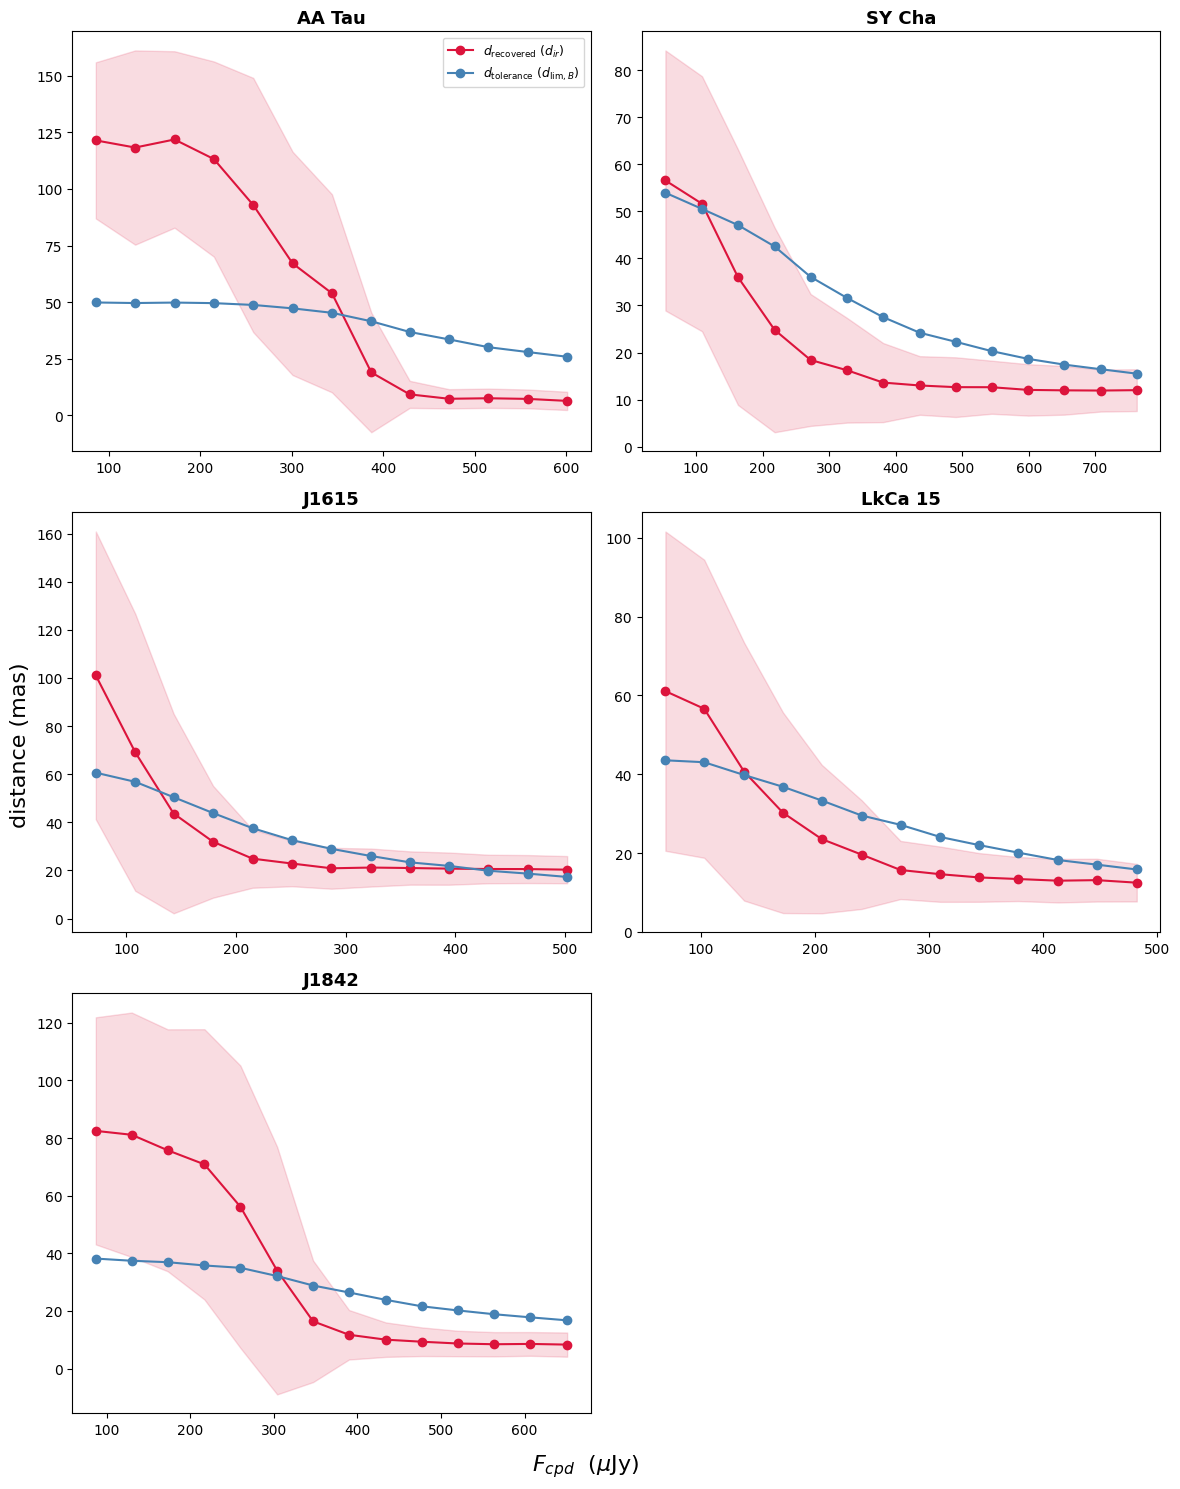

In [49]:
# d_recovered (= d_ir, the actual recovered-vs-injected distance for each mock)
# vs. d_tolerance (= dlim_B, Criterion B's allowed maximum distance) -- plotted
# together vs flux. Where the red line (d_ir) crosses above the blue line
# (dlim_B), most mocks start failing -- that crossing is what drives the decline.

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (folder, target, ix) in zip(axes.flat, Kink):
    PAr = np.radians(diskdict.disk[target]["PA"])
    inclr = np.radians(diskdict.disk[target]["incl"])

    fits_files = sorted(glob.glob(f"{kink_base_dir}/{folder}/recoveries/*.resid.fits"))
    hd = fits.open(fits_files[0])[0].header
    pix_size = np.abs(3600 * hd["CDELT2"])
    freq = hd["CRVAL3"]
    wave = 2.99792e5 / freq

    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    Bmax_km = (wave * np.sqrt(vdat["u"] ** 2 + vdat["v"] ** 2)).max()

    files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T

    azir = np.radians(azi)
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.sqrt((xi - xr) ** 2 + (yi - yr) ** 2)

    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size)

    Fcpd = np.unique(Fi)
    mean_dir = 1000 * np.array([d_ir[Fi == Fc].mean() for Fc in Fcpd])
    std_dir = 1000 * np.array([d_ir[Fi == Fc].std() for Fc in Fcpd])
    mean_dlimB = 1000 * np.array([dlim_B[Fi == Fc].mean() for Fc in Fcpd])

    ax.plot(Fcpd, mean_dir, "o-", color="crimson", label=r"$d_{\rm recovered}\ (d_{ir})$")
    ax.fill_between(Fcpd, mean_dir - std_dir, mean_dir + std_dir, color="crimson", alpha=0.15)
    ax.plot(Fcpd, mean_dlimB, "o-", color="steelblue", label=r"$d_{\rm tolerance}\ (d_{{\rm lim},B})$")
    ax.set_title(f"{target.replace('_', ' ')}", fontsize=13, fontweight="bold")

axes.flat[0].legend(fontsize=9)
for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=16)
fig.supylabel("distance (mas)", fontsize=16)
fig.tight_layout()
plt.show()

for j1615 can see the red shaded area is partly exceeding the blue curve at flux about 280jy , coinciding with the peak . And that the red curve shows at higher flux theres a constant positional offset of roughly 20 arcsec. dont know of what oriingin. for AA tau and J1842 is near zero.

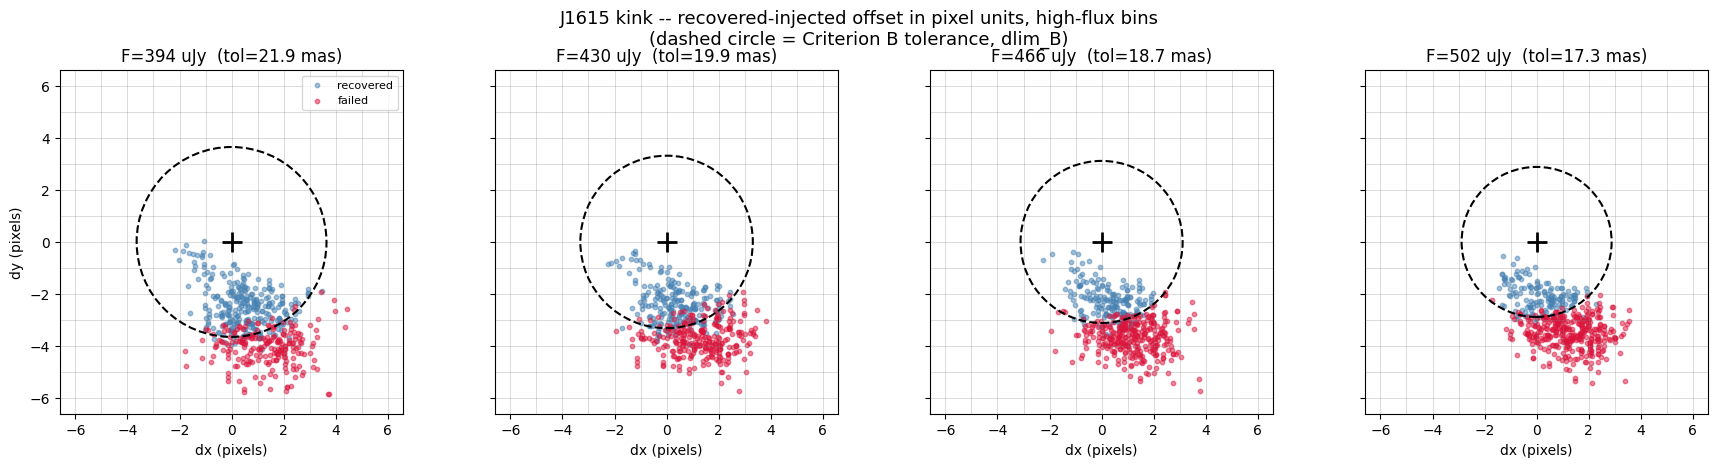

In [50]:
# J1615 kink, high-flux bins only: recovered-minus-injected position converted
# to PIXEL units (not mas) -- if this clusters on a fixed integer (or near-integer)
# (dx_pix, dy_pix), that's peak-pixel quantisation/gridding; if it clusters on a
# non-integer, non-small value instead, it's a real sub-pixel astrometric bias.
# Dashed circle = Criterion B's tolerance (dlim_B) for that bin -- points inside
# are the ones that actually pass the recovery criterion.

folder, target, ix = "J1615_kink0", "J1615", 2
check_bins = [394, 430, 466, 502]

PAr = np.radians(diskdict.disk[target]["PA"])
inclr = np.radians(diskdict.disk[target]["incl"])

fits_files = sorted(glob.glob(f"{kink_base_dir}/{folder}/recoveries/*.resid.fits"))
hd = fits.open(fits_files[0])[0].header
pix_size = np.abs(3600 * hd["CDELT2"])
freq = hd["CRVAL3"]
wave = 2.99792e5 / freq

vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
Bmax_km = (wave * np.sqrt(vdat["u"] ** 2 + vdat["v"] ** 2)).max()

files = sorted(glob.glob(f"{kink_base_dir}/{folder}*/recoveries/{target}_gap{ix}_recoveries.0.txt"))
Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.concatenate([np.loadtxt(f) for f in files]).T

azir = np.radians(azi)
xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)

dx_pix = (xr - xi) / pix_size
dy_pix = (yr - yi) / pix_size

sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size)
dlim_B_pix = dlim_B / pix_size

fig, axes = plt.subplots(1, len(check_bins), figsize=(4.5 * len(check_bins), 4.5), sharex=True, sharey=True)
for ax, fb in zip(axes, check_bins):
    Fc = Fi[np.argmin(np.abs(Fi - fb))]
    m = Fi == Fc
    is_rec = np.hypot(dx_pix[m], dy_pix[m]) <= dlim_B_pix[m]

    ax.scatter(dx_pix[m][is_rec], dy_pix[m][is_rec], s=10, alpha=0.5, color="steelblue", label="recovered")
    ax.scatter(dx_pix[m][~is_rec], dy_pix[m][~is_rec], s=10, alpha=0.5, color="crimson", label="failed")
    ax.scatter(0, 0, marker="+", s=200, color="k", linewidths=2, zorder=5)

    r_tol = dlim_B_pix[m].mean()
    ax.add_patch(plt.Circle((0, 0), r_tol, facecolor="none", edgecolor="k", ls="--", lw=1.5, zorder=4))

    for g in range(-6, 7):
        ax.axvline(g, color="grey", lw=0.4, alpha=0.5)
        ax.axhline(g, color="grey", lw=0.4, alpha=0.5)
    ax.set_aspect("equal")
    ax.set_title(f"F={Fc:.0f} uJy  (tol={r_tol * pix_size * 1000:.1f} mas)", fontsize=12)
    ax.set_xlabel("dx (pixels)")

axes[0].set_ylabel("dy (pixels)")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("J1615 kink -- recovered-injected offset in pixel units, high-flux bins\n(dashed circle = Criterion B tolerance, dlim_B)", fontsize=13)
fig.tight_layout()
plt.show()